# Brain Tumor Classification

With dataset merge step (training + testing) before preprocessing. Hence,

`Acquire -> Merge data from folders (Train & Test) -> train_test_split() merged data -> Preprocess -> Extract -> Classify -> Evaluate -> XAI`

## Preparation

### System Check

In [15]:
# Software check (OS)
!uname -a

# Hardware check (CPU, GPU, RAM)
!inxi

# Environment Check
!python --version
!code --version

Linux xt 6.17.0-22-generic #22~24.04.1-Ubuntu SMP PREEMPT_DYNAMIC Thu Mar 26 15:25:54 UTC 2 x86_64 x86_64 x86_64 GNU/Linux
CPU: 6-core AMD Ryzen 5 7640HS w/ Radeon 760M Graphics (-MT MCP-)
speed/min/max: 1575/410/5018 MHz Kernel: 6.17.0-22-generic x86_64 Up: 43m
Mem: 9.98/14.81 GiB (67.4%) Storage: 1.38 TiB (3.1% used) Procs: 424
Shell: python inxi: 3.3.34
Python 3.12.3
1.114.0
e7fb5e96c0730b9deb70b33781f98e2f35975036
x64


### Library Imports


In [16]:
# System
import os
from glob import glob
from zipfile import ZipFile
import pickle

# Utilities
import cv2 as cv
import matplotlib.pyplot as plt
import numpy as np
import time

# Data Preparation & Hyperparameter Tuning
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# LBP Library
from skimage.feature import local_binary_pattern

# Classical Machine Learning Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier 
from sklearn.naive_bayes import MultinomialNB, GaussianNB
from sklearn.svm import LinearSVC
from sklearn.svm import SVC

# Deep Learning CNN Model
import keras
from keras import layers
from keras.callbacks import EarlyStopping

# Evaluation Functions
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# LIME XAI
from lime import lime_image
from skimage.segmentation import mark_boundaries

### Global Variable(s)

In [17]:
# Image size for resize process of preprocessing step
IMAGE_SIZE = 128
CNN_IMAGE_SIZE = 128

# List of utilized feature extraction methods and their parameters
FEATURES = ["lbplib", "lbp", "lbpu",
            "nlbp1", "nlbp2", "nlbp3", "nlbp4", 
            "albp0", "albp45", "albp90", "albp135", 
            "mblbp2", "mblbp3", "mblbp4", 
            "semblbp2", "semblbp3", "semblbp4"]

# Reproducibility seeds configuration
np.random.seed(42)
keras.utils.set_random_seed(42)

## Dataset Acquisition


### File Extraction

In [18]:
dataset_path = "./data/"
dataset_file = dataset_path + "brain-sartaj.zip"

# Extract zipped dataset file
zipfile = ZipFile(dataset_file)
zipfile.extractall(dataset_path)
zipfile.close()

print("Dataset File & Folders:", os.listdir(dataset_path))

Dataset File & Folders: ['Training', 'Testing', 'brain-sartaj.zip']


In [19]:
train_path = os.path.join(dataset_path, "Training")
test_path = os.path.join(dataset_path, "Testing")

# List of dataset classes/labels
classes = sorted(os.listdir(train_path))

print("Dataset Classes:", classes)

Dataset Classes: ['glioma_tumor', 'meningioma_tumor', 'no_tumor', 'pituitary_tumor']


### Train & Test Merge

In [20]:
# Data and labels from merged Training and Testing folders
X, y = [], []

for idx, label in enumerate(classes):
    # Input Training folder image data and labels to merged lists
    train_images = glob(os.path.join(train_path, label, "*.jpg"))
    for img_raw in train_images:
        img = cv.imread(img_raw)
        X.append(img)
        y.append(idx)
    
    # Input Testing folder image data and labels to merged lists
    test_images = glob(os.path.join(test_path, label, "*.jpg"))
    for img_raw in test_images:
        img = cv.imread(img_raw)
        X.append(img)
        y.append(idx)

print("X\ty")
print(f"{len(X)}\t{len(y)}")

X	y
3264	3264


### Train & Test Split

In [21]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2,  # 80:20 Train:Test Ratio
    stratify=y,
    random_state=42,
)

print("X_train\ty_train\t")
print(f"{len(X_train)}\t{len(y_train)}\n")
print("X_test\ty_test\t")
print(f"{len(X_test)}\t{len(y_test)}\t")

X_train	y_train	
2611	2611

X_test	y_test	
653	653	


## Classical Machine Learning

### ML - Preprocessing

In [23]:
# Data preprocessing function for machine learning classifiers
def preprocess_ml(images):
    preprocessed = []

    for img in images:
        # Resize image into same resolutions
        img_resized = cv.resize(img, (IMAGE_SIZE, IMAGE_SIZE))

        # Convert image from BGR (3-channels) to grayscale (1-channel)
        img_grayscaled = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)
        
        preprocessed.append(img_grayscaled)
    
    return preprocessed

In [24]:
# Preprocess dataset for machine learning classifier feature extractions
X_train_prep = preprocess_ml(X_train)
X_test_prep = preprocess_ml(X_test)

print("X_train_prep\ty_train")
print(f"{len(X_train_prep)}\t\t{len(y_train)}\n")
print("X_test_prep\ty_test")
print(f"{len(X_test_prep)}\t\t{len(y_test)}")

X_train_prep	y_train
2611		2611

X_test_prep	y_test
653		653


#### Preprocessed Dataset Preview

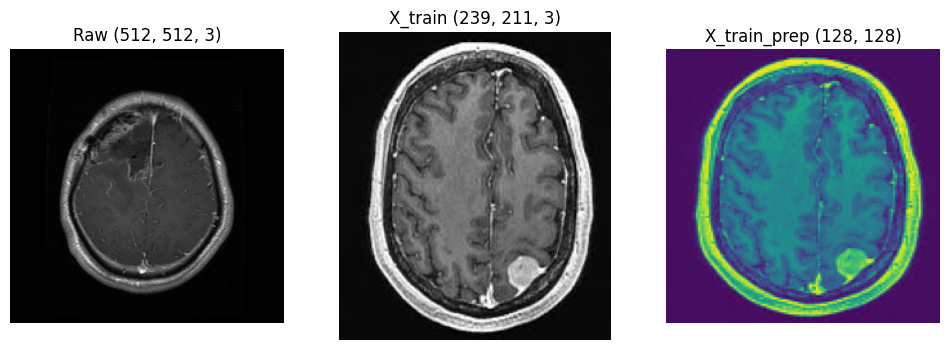

In [117]:
prvw_idx = 21
plt.figure(figsize=(12,4))

# Raw (merged) dataset sample
plt.subplot(1, 3, 1)
plt.title(f"Raw {X[prvw_idx].shape}")
plt.axis('off')
plt.imshow(X[prvw_idx])

# Train dataset sample
plt.subplot(1, 3, 2)
plt.title(f"X_train {X_train[prvw_idx].shape}")
plt.axis('off')
plt.imshow(X_train[prvw_idx])

# Preprocessed train dataset sample
plt.subplot(1,3,3)
plt.title(f"X_train_prep {X_train_prep[prvw_idx].shape}")
plt.axis('off')
plt.imshow(X_train_prep[prvw_idx])

plt.show()

### ML - Feature Extraction

In [26]:
# Convert binary list value to decimal representation
def get_decimal(binary, uniform=True):
    transition = 0
    decimal = 0

    # Assign each binary digit to its decimal weight
    for i in range(8):
        # Count transitions by comparing current bit with the next bit
        next_bit = (i+1) % 8
        # Add the transition count if those two bit values are different
        transition += binary[i] != binary[next_bit]
        # Convert every bit of a binary list into its decimal value
        decimal = decimal * 2 + binary[i]

    # Uniform pattern filtering for classical LBP
    if(uniform): return decimal if(transition <= 2) else 256

    return decimal

# Get histogram representation of image feature
def get_histogram(img, non_uniform=0, library=False):
    histogram, _ = np.histogram(a=img, bins=[x for x in range(257)])
    uniform_histogram = []

    # LBP with non-uniform histogram simplification
    if(non_uniform > 0):
        # Delete zero values throughout the list
        uniform_histogram = np.delete(histogram, np.where(histogram == 0))
        # Append non uniform value into 59th element of the uniform pattern histogram 
        uniform_histogram = np.append(uniform_histogram, non_uniform)
        return uniform_histogram
    
    # LBP histogram simplification from built-in sklearn library
    if(library):
        # Delete zero values from histogram
        histogram = np.delete(histogram, np.where(histogram == 0))

    return histogram

In [27]:
# Neighboring pixels' coordinates of the center pixel
P_COORDS = [(-1, -1), (-1, 0), (-1, 1), # (top left) (top center) (top right)
            ( 0,  1),                   # (center right)
            ( 1,  1), ( 1, 0), (1, -1), # (bottom right) (bottom center) (bottom left)
            ( 0, -1)]                   # (center left)

#### Classic LBP

In [28]:
def get_lbp(img, uniform=True):
    height, width = img.shape
    # Add padding to image edges with the value of 0
    img_pad = np.pad(img, pad_width=1, mode="constant", constant_values=0)
    img_lbp = np.zeros((height, width), np.uint8)
    non_uniform = 0

    for i in range(height):
        for j in range(width):
            # Center pixel on padded image
            c_i, c_j = i+1, j+1
            c = img_pad[c_i, c_j]

            # Center pixel's binary representation
            c_bin = []

            for p_coord in P_COORDS:
                # Neighboring pixels of center pixel
                p = img_pad[c_i + p_coord[0], c_j + p_coord[1]]

                # Threshold and append bit value to pixel representation
                c_bin.append(1 if(p >= c) else 0)

            # Convert center pixel's binary representation to its decimal value
            decimal = get_decimal(c_bin, uniform=uniform)
            # Filter non-uniform pattern
            if(decimal == 256): non_uniform += 1
            # Assign uniform decimal value
            else: img_lbp[i][j] = decimal

    # Get relevant feature vector histogram based on the created feature image
    hist_lbp = get_histogram(img_lbp, non_uniform)

    return img_lbp, hist_lbp

#### nLBP


In [29]:
def get_nlbp(img, distance):
    height, width = img.shape
    img_pad = np.pad(img, pad_width=1, mode="constant", constant_values=0)
    img_nlbp = np.zeros((height, width), np.uint8)

    for i in range(height):
        for j in range(width):
            # Center pixel's coordinates on padded image
            c_i, c_j = i+1, j+1

            c_bin = []

            for p in range(8):
                # First neighboring pixel to compare
                p_a = img_pad[c_i + P_COORDS[p][0], c_j + P_COORDS[p][1]]
                
                # Second neighboring pixel to compare
                p_b_idx = (p+distance) % 8
                p_b = img_pad[c_i + P_COORDS[p_b_idx][0], c_j + P_COORDS[p_b_idx][1]]

                # Compare first with second neighboring pixels
                # Append bit value to pixel's binary representation
                c_bin.append(1 if(p_a >= p_b) else 0)

            # Convert & assign every center pixel's binary representations to its decimal values
            decimal = get_decimal(c_bin, uniform=False)
            img_nlbp[i][j] = decimal

    hist_nlbp = get_histogram(img_nlbp)

    return img_nlbp, hist_nlbp

#### αLBP


In [30]:
def get_albp(img, alpha, neighbors=8):
    height, width = img.shape
    # Add image paddings as much as half of the neighboring pixels
    img_pad = np.pad(img, pad_width=neighbors//2, mode="constant", constant_values=0)
    img_albp = np.zeros((height, width), np.uint8)

    # Neighboring pixels' coordinate candidates based on the chosen alpha parameter
    p_coords_list = {
        0  : [( 0, 4), ( 0, 3), ( 0, 2), ( 0, 1), ( 0,-1), ( 0,-2), ( 0,-3), ( 0,-4)],
        45 : [(-4, 4), (-3, 3), (-2, 2), (-1, 1), ( 1,-1), ( 2,-2), ( 3,-3), ( 4,-4)],
        90 : [(-4, 0), (-3, 0), (-2, 0), (-1, 0), ( 1, 0), ( 2, 0), ( 3, 0), ( 4, 0)],
        135: [(-4,-4), (-3,-3), (-2,-2), (-1,-1), ( 1, 1), ( 2, 2), ( 3, 3), ( 4, 4)],
    }

    # Handle alpha parameter input outside the scope
    if(alpha % 360 not in p_coords_list.keys()):
        return print("Incorrect alpha parameter value")

    for i in range(height):
        for j in range(width):
            # Center pixel on padded image
            c_i, c_j = i+(neighbors//2), j+(neighbors//2)
            c = img_pad[c_i][c_j]
            
            # Chosen neighboring pixels from alpha parameter
            p_coords = p_coords_list[alpha]

            c_bin = []

            for p in p_coords:
                # Coordinates of the neighboring pixels based on their center
                p_i_crd = c_i + p[0] # Y plane
                p_j_crd = c_j + p[1] # X plane
                
                # Neighboring pixel to be compared with the center pixel 
                p = img_pad[p_i_crd, p_j_crd]

                # Compare center pixel with current neighboring pixel
                # Append bit value to pixel's binary representation
                c_bin.append(1 if p >= c else 0)

            decimal = get_decimal(c_bin, uniform=False)
            img_albp[i][j] = decimal

    hist_albp = get_histogram(img_albp)

    return img_albp, hist_albp

#### MB-LBP (and SEMB-LBP)

In [31]:
def get_integral_image(img):
    height, width = img.shape
    
    img_integral = np.zeros((height, width), int)
    img_integral_pad = np.pad(img_integral, pad_width=1, mode="constant", constant_values=0)
    
    for i in range(height):
        for j in range(width):
            # Get the current pixel's integral image value 
            # by adding its pixel intensity value with its above and left side of integral image value
            # then subtract overlapping values from the top-left side 
            img_integral_pad[i][j] = img[i][j] + img_integral_pad[i-1][j] + img_integral_pad[i][j-1] - img_integral_pad[i-1][j-1]

    # Return image integral result with removed zero paddings
    return img_integral_pad[:-2,:-2]

def get_semblbp_histogram(img, v):
    # Top n features to preserve its values
    n = 63    # Image region histogram from MB-LBP features
    semb_hist = get_histogram(img)
    # Descendingly sorted indices of mostly appeared features in image histogram
    semb_sorted_idx = np.argsort(semb_hist)[::-1]
    # SEMB-LBP image features
    # Keep the n mostly appeared feature values,
    # Set the rest (>=n+1)th mostly appeared values to v 
    semb_sorted = np.array([(semb_hist[i]) if i in semb_sorted_idx[:n] else v for i in range(256)])

    return semb_sorted

def get_mblbp(img, region_size, v=0):
    height, width = img.shape

    # Rounded (ceiling division) size values from base image to get the region image size
    region_height = -(-height // region_size)
    region_width = -(-width // region_size)

    img_integral = get_integral_image(img)
    img_region = np.zeros((region_height, region_width), int)
    img_pad = np.pad(img_integral, pad_width=region_size, mode="constant", constant_values=0)

    for i in range(region_height):
        for j in range(region_width):
            # Integral image variables
            # Top-Left
            a = img_pad[i*region_size-1, j*region_size-1] if(i*region_size-1>=0 and j*region_size-1>=0) else 0
            # Top-Right
            b = img_pad[i*region_size-1, j*region_size+region_size-1] if(i*region_size-1>=0 and j*region_size+region_size-1>=0) else 0
            # Bottom-Left
            c = img_pad[i*region_size+region_size-1, j*region_size-1] if(i*region_size+region_size-1>=0 and j*region_size-1>=0) else 0
            # Bottom-Right
            d = img_pad[i*region_size+region_size-1, j*region_size+region_size-1]
            
            # Region's sum and mean value using integral image formula
            region_sum = d - b - c + a
            img_region[i][j] = region_sum // (region_size*region_size)

    # MB-LBP image feature
    img_mblbp, hist_mblbp = get_lbp(img_region, uniform=False)

    # Override histogram for SEMB-LBP 
    # v parameter to set the values of less frequent features
    if(v > 0): hist_mblbp = get_semblbp_histogram(img_mblbp, v)

    return img_mblbp, hist_mblbp

#### Feature Extraction Process

In [32]:
# Feature extraction process for each methods
def get_feature_histogram(image, method, param=None, v=None):
    match method:
        # Local binary pattern using library from scikit-learn
        case "lbplib":
            feat = local_binary_pattern(image, P=8, R=1, method="nri_uniform")
            hist = get_histogram(feat, library=True)
        # Local binary pattern from scratch
        case "lbp":
            feat, hist = get_lbp(image, uniform=False)
        case "lbpu":
            feat, hist = get_lbp(image, uniform=True)
        case "nlbp":
            feat, hist = get_nlbp(image, param)
        case "albp":
            feat, hist = get_albp(image, param)
        case "mblbp":
            feat, hist = get_mblbp(image, param)
        # SEMB-LBP
        case _:
            feat, hist = get_mblbp(image, param, v)

    return feat, hist

# Feature extraction function for train and test set
def get_features(images, method, param=None, v=None):
    print(method, str(param).ljust(4), sep="\t", end="\t")

    start_feature_extractions = time.perf_counter()
    
    # Created image features and histograms of all image set
    features, histograms = [], []

    for image in images:
        # Each image's extracted image feature & histograms
        img_feature, img_histogram = get_feature_histogram(image, method, param, v)

        features.append(img_feature)
        histograms.append(img_histogram)
        
    print(f"{time.perf_counter() - start_feature_extractions}s.")

    return features, histograms

In [33]:
print(f"Extracting Features: Train Set ({len(X_train_prep)} images)\n")
print("Method", "Param", "Time", sep="\t")

train_fe_time_start = time.perf_counter()

X_train_lbplib, X_train_lbplib_hist = get_features(X_train_prep, "lbplib")        
X_train_lbp, X_train_lbp_hist = get_features(X_train_prep, "lbp")                  
X_train_lbpu, X_train_lbpu_hist = get_features(X_train_prep, "lbpu")                  

X_train_nlbp1, X_train_nlbp1_hist = get_features(X_train_prep, "nlbp", 1)          
X_train_nlbp2, X_train_nlbp2_hist = get_features(X_train_prep, "nlbp", 2)          
X_train_nlbp3, X_train_nlbp3_hist = get_features(X_train_prep, "nlbp", 3)          
X_train_nlbp4, X_train_nlbp4_hist = get_features(X_train_prep, "nlbp", 4)          

X_train_albp0, X_train_albp0_hist = get_features(X_train_prep, "albp", 0)          
X_train_albp45, X_train_albp45_hist = get_features(X_train_prep, "albp", 45)       
X_train_albp90, X_train_albp90_hist = get_features(X_train_prep, "albp", 90)       
X_train_albp135, X_train_albp135_hist = get_features(X_train_prep, "albp", 135)    

X_train_mblbp2, X_train_mblbp2_hist = get_features(X_train_prep, "mblbp", 2)       
X_train_mblbp3, X_train_mblbp3_hist = get_features(X_train_prep, "mblbp", 3)       
X_train_mblbp4, X_train_mblbp4_hist = get_features(X_train_prep, "mblbp", 4)       

X_train_semblbp2, X_train_semblbp2_hist = get_features(X_train_prep, "semb", 2, 63)
X_train_semblbp3, X_train_semblbp3_hist = get_features(X_train_prep, "semb", 3, 31)
X_train_semblbp4, X_train_semblbp4_hist = get_features(X_train_prep, "semb", 4, 15)

print(f"\nAll Features Extracted in {time.perf_counter() - train_fe_time_start}s")

Extracting Features: Train Set (2611 images)

Method	Param	Time
lbplib	None	5.876569092999944s.
lbp	None	76.77503016399987s.
lbpu	None	78.47454030400013s.
nlbp	1   	119.66600153799982s.
nlbp	2   	121.00480261400025s.
nlbp	3   	122.37552987800018s.
nlbp	4   	116.5379507700004s.
albp	0   	86.3620430369997s.
albp	45  	85.73114365099991s.
albp	90  	86.58568740999999s.
albp	135 	85.51492591600027s.
mblbp	2   	61.78666093399988s.
mblbp	3   	47.08401041199977s.
mblbp	4   	41.75901902100031s.
semb	2   	63.32883609500004s.
semb	3   	48.43527317100006s.
semb	4   	42.166493978999824s.

All Features Extracted in 1289.4915224439997s


In [34]:
# Store extracted image features to reduce redundancy
X_train_feats = [X_train_lbplib, X_train_lbp, X_train_lbpu,
                 X_train_nlbp1, X_train_nlbp2, X_train_nlbp3, X_train_nlbp4,
                 X_train_albp0, X_train_albp45, X_train_albp90, X_train_albp135, 
                 X_train_mblbp2, X_train_mblbp3, X_train_mblbp4,
                 X_train_semblbp2, X_train_semblbp3, X_train_semblbp4]

# Store extracted histograms to reduce redundancy
X_train_hists = [X_train_lbplib_hist, X_train_lbp_hist, X_train_lbpu_hist,
                 X_train_nlbp1_hist, X_train_nlbp2_hist, X_train_nlbp3_hist, X_train_nlbp4_hist, 
                 X_train_albp0_hist, X_train_albp45_hist, X_train_albp90_hist, X_train_albp135_hist, 
                 X_train_mblbp2_hist, X_train_mblbp3_hist, X_train_mblbp4_hist,
                 X_train_semblbp2_hist, X_train_semblbp3_hist, X_train_semblbp4_hist]

#### Feature Extraction Data

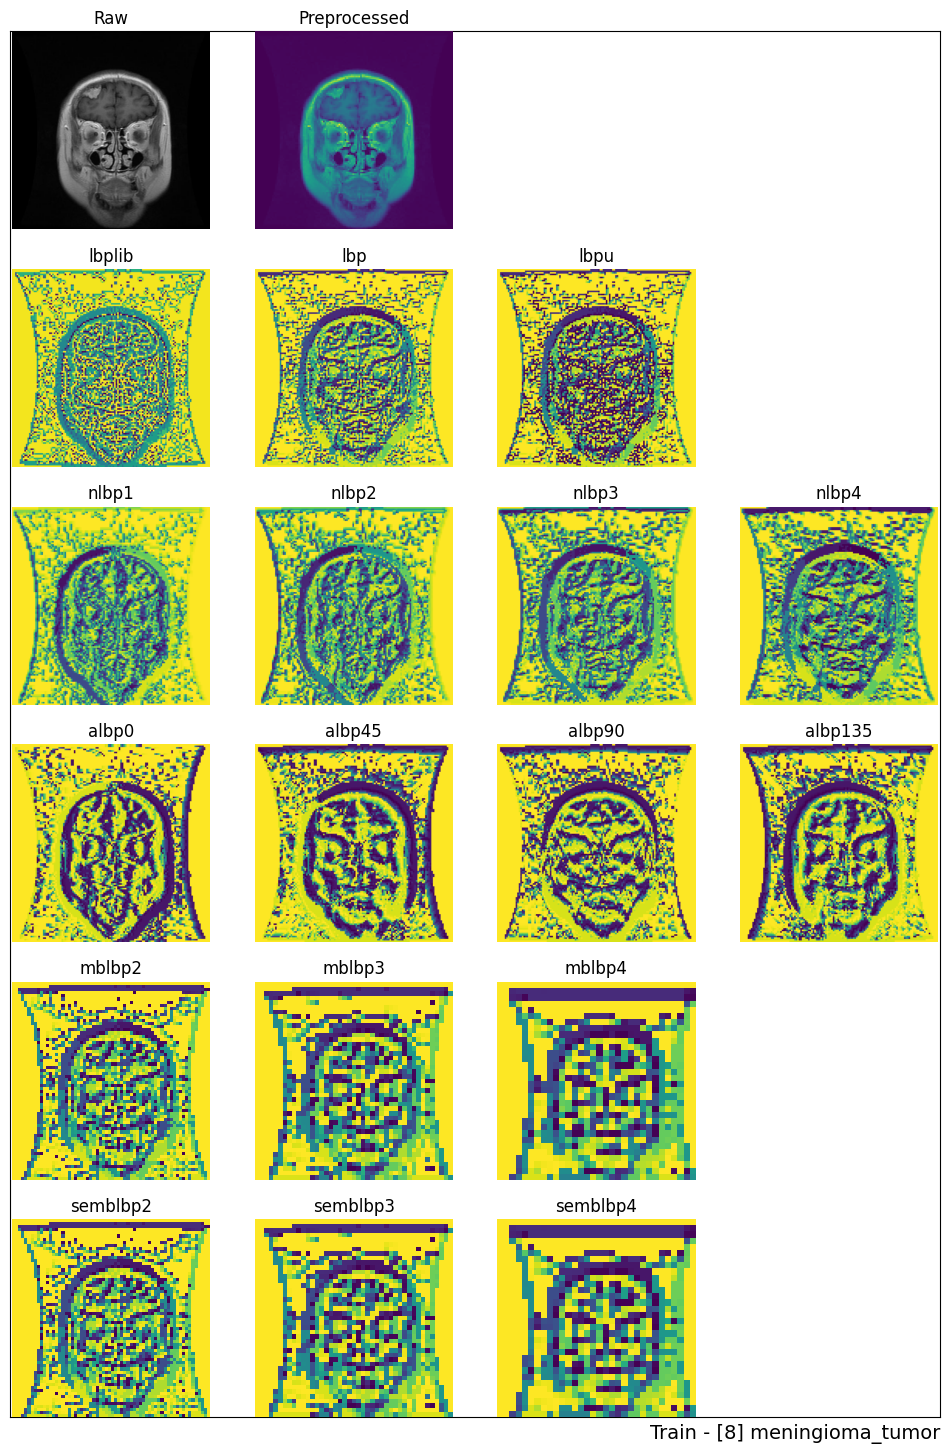

In [111]:
prvw_idx = 8
# Sample images to be previewed
prvw_train_data = [X_train[prvw_idx], X_train_prep[prvw_idx]]
for f in X_train_feats:
    prvw_train_data.append(f[prvw_idx])
# Sample subplot titles
prvw_titles = ["Raw", "Preprocessed", *FEATURES]
# Image subplot positions
prvw_img_pos = [1, 2, 5, 6, 7, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23]

# Plot configurations
plt.figure(figsize=(12, 18))
plt.xlabel(f"Train - [{prvw_idx}] {classes[y_train[prvw_idx]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

def get_image_preview(title, data, idx):
    plt.subplot(6, 4, idx)
    plt.axis("off")
    plt.title(title)
    plt.imshow(data)

# Preview all image samples
for i in range(len(prvw_titles)):
    get_image_preview(prvw_titles[i], prvw_train_data[i], prvw_img_pos[i])

plt.show()

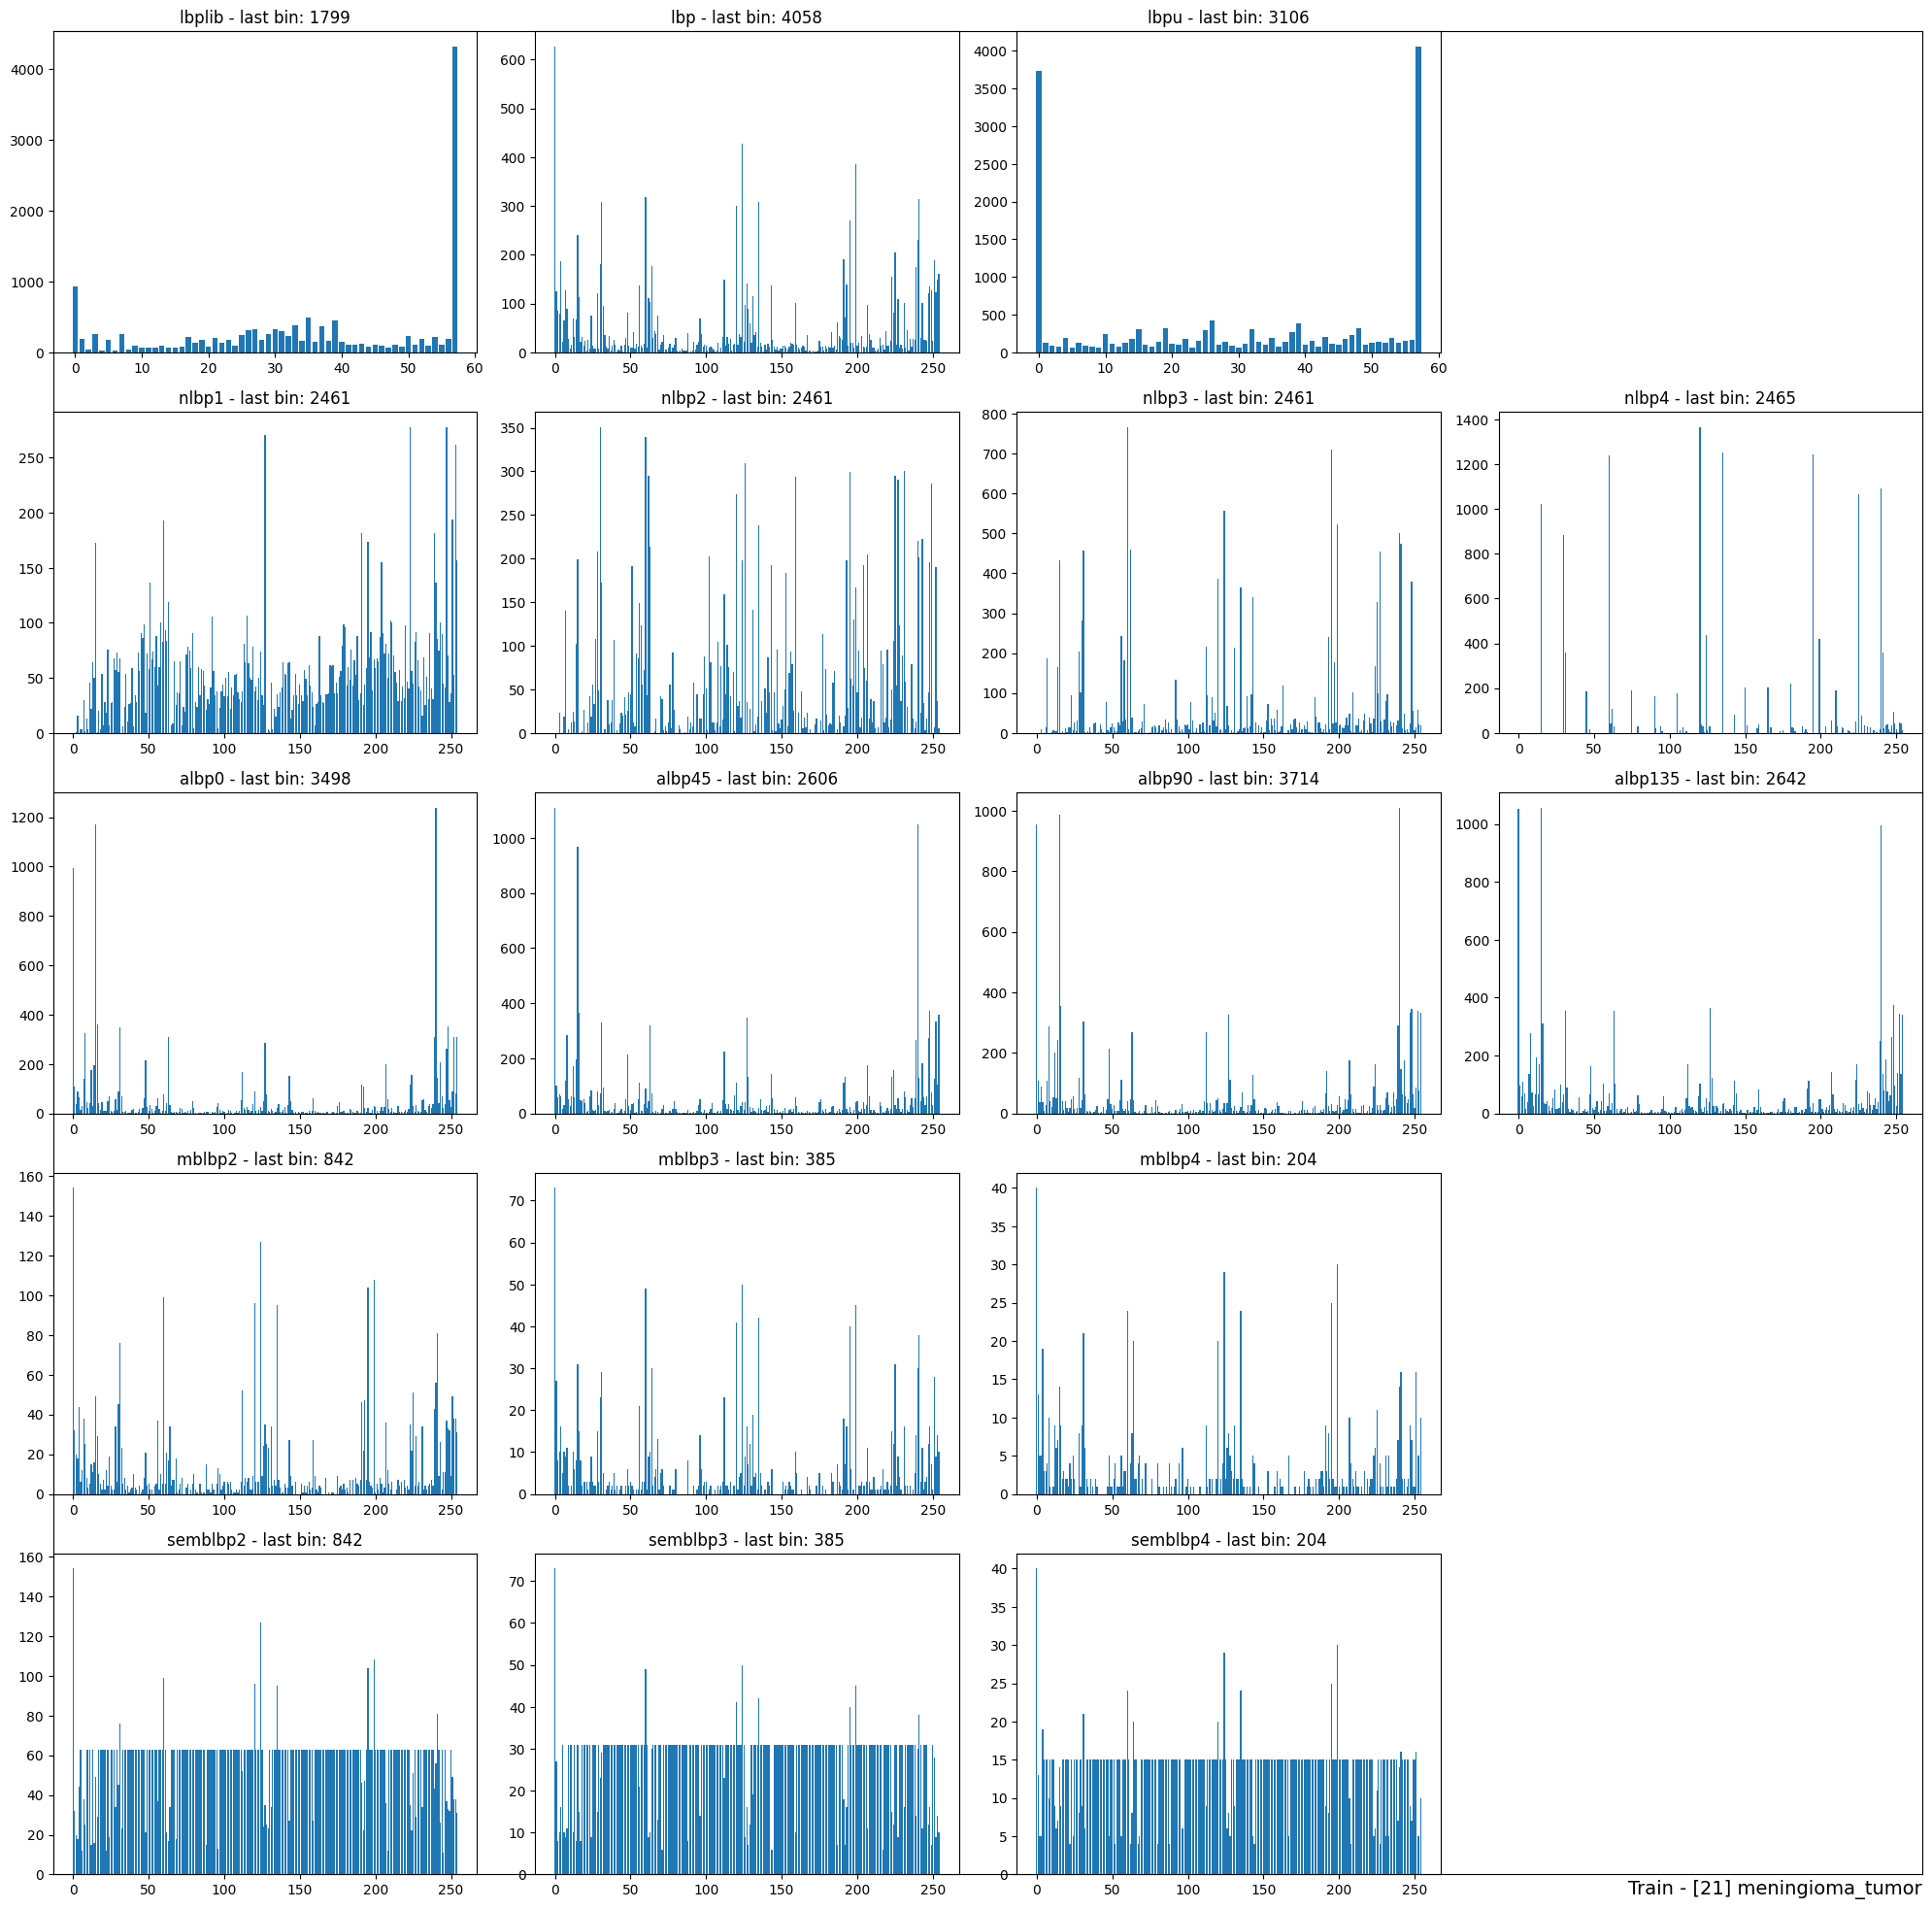

In [ ]:
# Histogram subplot positions
prvw_hist_pos = [1, 2, 3, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 17, 18, 19]

plt.figure(figsize=(20, 20))
# Plot configurations
plt.xlabel(f"Train - [{prvw_idx}] {classes[y_train[prvw_idx]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

def get_histogram_preview(title, data, idx):
    plt.subplot(5, 4, idx)
    plt.tight_layout()
    plt.title(f"{title} - last bin: {str(data[-1])}")
    plt.bar(np.arange(len(data[:-1])), data[:-1])

# Preview all extracted histogram feature samples
for i in range(len(X_train_hists)):    
    get_histogram_preview(prvw_titles[2:][i], X_train_hists[i][prvw_idx], prvw_hist_pos[i])

plt.show()

### ML - Classification

In [37]:
# Machine learning model cross validation and training function
def get_model(i, method, base_model, param_grid, X_train_model, scale=False):
    print(f"{str(i).ljust(2)} {method}".ljust(8), end="\t")

    # Begin modelling time counting
    start_modelling_time = time.perf_counter()

    # Sequence of feature vectors processing
    pipe = Pipeline([
        # Scale the feature vectors
        ("scaler", StandardScaler()) if scale else ("scaler", "passthrough"),
        ("classifier", base_model),
    ])

    # Model cross validating and hyperparameter tuning
    classifier = GridSearchCV(estimator=pipe,
                              param_grid=param_grid,
                              scoring="f1_macro",   # Handle imbalanced dataset with same weights of classes
                              n_jobs=-1,            # Utilize all available processors
                              cv=5,
                              verbose=0)
    # Train & fit model with extracted features and labels
    classifier.fit(X_train_model, y_train)

    modelling_time = time.perf_counter() - start_modelling_time

    print(f"{round(classifier.best_score_, 6)}".ljust(8),
          f"{round(modelling_time, 6)}s".ljust(10),
          f"{classifier.best_params_}",
          sep="\t")
    
    # Store model performance result in a map for better accessibility
    result = {
        "method": method, 
        "model": classifier, 
        "time": modelling_time
    }

    return result

# Machine learning bulk modelling function for all feature extraction methods
def get_models(title, base_model, param_grid, X_train_model, scale=False):
    ml_models = []
    
    print(f">  {title}\n")
    print("   Method", "Score", "\tTime", "\tParameters", sep="\t")

    for i, feature in enumerate(FEATURES):
        # Train and store models with each features
        model = get_model(i, feature, base_model, param_grid, X_train_model[i], scale)
        ml_models.append(model)

    return ml_models

def get_best_models(models, model_title):
    # Sort models descendingly based on their cross validation evaluation (f1_macro) scores
    sorted_models = sorted(models, key=lambda x:x["model"].best_score_, reverse=True)
    # Best model by the best score of sorted models
    best_model = sorted_models[0]

    print(f"\nBest Method\t> {model_title} > {best_model["method"]}")
    print(f"Best Params\t> {best_model["model"].best_params_}")
    print(f"Best Score\t> {best_model["model"].best_score_}")
    print(f"Best Time\t> {best_model["time"]}s")
    print(f"\nCV Time\t\t>", end=" ")

    return best_model

#### K-Nearest Neighbors

In [38]:
knn_time_start = time.perf_counter()

knn_title = "K-Nearest Neighbors"
knn_base_model = KNeighborsClassifier()
knn_param_grid = {
    "classifier__n_neighbors": [1, 3, 5, 9],
    "classifier__weights": ["uniform", "distance"],
    "classifier__metric": ["manhattan", "euclidean", "cosine"]
}

knn_models = get_models(knn_title, knn_base_model, knn_param_grid, X_train_hists)
knn_best = get_best_models(knn_models, knn_title)

print(f"{time.perf_counter() - knn_time_start}s")
# .861 2.61

>  K-Nearest Neighbors

   Method	Score		Time		Parameters
0  lbplib	0.832318	4.687741s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
1  lbp  	0.862575	3.607785s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
2  lbpu 	0.807502	1.821511s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
3  nlbp1	0.86405 	3.212618s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
4  nlbp2	0.858351	3.153766s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
5  nlbp3	0.860227	3.11499s  	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
6  nlbp4	0.834691	3.144784s 	{'classifier__metric': 'manhattan', 'classifier__n_neighbors': 1, 'classifier__weights': 'uniform'}
7  albp0	0.819388	3.139035s 	{'classif

#### Decision Tree

In [39]:
dt_time_start = time.perf_counter()

dt_title = "Decision Tree"
dt_base_model = DecisionTreeClassifier()
dt_param_grid = {
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__min_samples_split": [2, 3, 5],
    "classifier__min_samples_leaf": [1, 2, 3],
}

dt_models = get_models(dt_title, dt_base_model, dt_param_grid, X_train_hists)
dt_best = get_best_models(dt_models, dt_title)

print(f"{time.perf_counter() - dt_time_start}s")
# .740 7.3

>  Decision Tree

   Method	Score		Time		Parameters
0  lbplib	0.710136	8.129886s 	{'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
1  lbp  	0.704106	21.056968s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
2  lbpu 	0.717015	7.85296s  	{'classifier__criterion': 'gini', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
3  nlbp1	0.729536	22.018298s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
4  nlbp2	0.723182	21.019231s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
5  nlbp3	0.708776	20.966976s	{'classifier__criterion': 'gini', 'classifier__max_depth': 10, 'classifier__min_sample

#### Random Forest

In [40]:
rf_time_start = time.perf_counter()

rf_title = "Random Forest"
rf_base_model = RandomForestClassifier()
rf_param_grid = {
    "classifier__n_estimators": [100, 150, 200],
    "classifier__criterion": ["gini", "entropy", "log_loss"],
    "classifier__max_depth": [None, 20],
    "classifier__min_samples_leaf": [1, 2],
}

rf_models = get_models(rf_title, rf_base_model, rf_param_grid, X_train_hists)
rf_best = get_best_models(rf_models, rf_title)

print(f"{time.perf_counter() - rf_time_start}s")
# .835 46.8

>  Random Forest

   Method	Score		Time		Parameters
0  lbplib	0.817925	26.701393s	{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 150}
1  lbp  	0.791837	38.789752s	{'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 150}
2  lbpu 	0.818537	26.778386s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
3  nlbp1	0.822081	41.061361s	{'classifier__criterion': 'entropy', 'classifier__max_depth': None, 'classifier__min_samples_leaf': 2, 'classifier__n_estimators': 150}
4  nlbp2	0.824723	35.881336s	{'classifier__criterion': 'log_loss', 'classifier__max_depth': 20, 'classifier__min_samples_leaf': 1, 'classifier__n_estimators': 200}
5  nlbp3	0.813633	35.109598s	{'classifier__criterion': 'entropy', 'classifier__max_depth': 20, 'classifier__min_samples_leaf':

#### Naive Bayes

Multinomial Naive Bayes

In [ ]:
mnb_time_start = time.perf_counter()

mnb_title = "Multinomial Naive Bayes"
mnb_base_model = MultinomialNB()
mnb_param_grid = {
    "classifier__alpha": [0.1, 0.5, 1.0, 2.0],
    "classifier__fit_prior": [True, False]
}

mnb_models = get_models(mnb_title, mnb_base_model, mnb_param_grid, X_train_hists)
mnb_best = get_best_models(mnb_models, mnb_title)

print(f"{time.perf_counter() - mnb_time_start}s")
# .525 .91

>  Multinomial Naive Bayes

   Method	Score		Time		Parameters
0  lbplib	0.454375	0.944686s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
1  lbp  	0.460229	1.380588s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
2  lbpu 	0.451646	0.95265s  	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
3  nlbp1	0.50063 	1.438932s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
4  nlbp2	0.484603	1.498722s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
5  nlbp3	0.472408	1.440767s 	{'classifier__alpha': 2.0, 'classifier__fit_prior': False}
6  nlbp4	0.488656	1.367427s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
7  albp0	0.456   	1.295228s 	{'classifier__alpha': 1.0, 'classifier__fit_prior': True}
8  albp45	0.435666	1.320546s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
9  albp90	0.47068 	1.295351s 	{'classifier__alpha': 0.1, 'classifier__fit_prior': True}
10 albp135	0.429763	1.378579s 	{'classifier__alpha': 0.1, 'class

Gaussian Naive Bayes

In [42]:
gnb_time_start = time.perf_counter()

gnb_title = "Gaussian Naive Bayes"
gnb_base_model = GaussianNB()
gnb_param_grid = {
    "classifier__var_smoothing": [1e-12, 1e-11, 1e-10, 1e-9, 1e-8]
}

gnb_models = get_models(gnb_title, gnb_base_model, gnb_param_grid, X_train_hists)
gnb_best = get_best_models(gnb_models, gnb_title)

print(f"{time.perf_counter() - gnb_time_start}s")
# .588 .57

>  Gaussian Naive Bayes

   Method	Score		Time		Parameters
0  lbplib	0.53153 	0.653811s 	{'classifier__var_smoothing': 1e-12}
1  lbp  	0.519068	0.879274s 	{'classifier__var_smoothing': 1e-09}
2  lbpu 	0.529286	0.609123s 	{'classifier__var_smoothing': 1e-12}
3  nlbp1	0.550061	0.791638s 	{'classifier__var_smoothing': 1e-12}
4  nlbp2	0.592441	0.799392s 	{'classifier__var_smoothing': 1e-12}
5  nlbp3	0.564847	0.809428s 	{'classifier__var_smoothing': 1e-08}
6  nlbp4	0.578209	0.796389s 	{'classifier__var_smoothing': 1e-08}
7  albp0	0.531978	0.838139s 	{'classifier__var_smoothing': 1e-12}
8  albp45	0.475294	0.849915s 	{'classifier__var_smoothing': 1e-08}
9  albp90	0.47622 	0.853035s 	{'classifier__var_smoothing': 1e-08}
10 albp135	0.469773	0.807779s 	{'classifier__var_smoothing': 1e-12}
11 mblbp2	0.494662	0.836037s 	{'classifier__var_smoothing': 1e-12}
12 mblbp3	0.521945	0.838424s 	{'classifier__var_smoothing': 1e-12}
13 mblbp4	0.557848	0.811201s 	{'classifier__var_smoothing': 1e-12}
14 semblb

#### Support Vector Machine

##### Linear

LinearSVC Library

In [43]:
svm_linearlib_time_start = time.perf_counter()

svm_linearlib_title = "(Scaled) Support Vector Machine - Linear Kernel (LinearSVC)"
svm_linearlib_base_model = LinearSVC(random_state=42)
svm_linearlib_param_grid = {
    "classifier__C": [0.001, 0.01, 0.1, 1],
    "classifier__dual": [False],
}

svm_linearlib_models = get_models(svm_linearlib_title, svm_linearlib_base_model, svm_linearlib_param_grid, X_train_hists, scale=True)
svm_linearlib_best = get_best_models(svm_linearlib_models, svm_linearlib_title)

print(f"{time.perf_counter() - svm_linearlib_time_start}s")
# .771 3.10

>  (Scaled) Support Vector Machine - Linear Kernel (LinearSVC)

   Method	Score		Time		Parameters
0  lbplib	0.674406	0.608247s 	{'classifier__C': 1, 'classifier__dual': False}
1  lbp  	0.726678	2.689386s 	{'classifier__C': 0.001, 'classifier__dual': False}
2  lbpu 	0.679158	0.606248s 	{'classifier__C': 0.1, 'classifier__dual': False}
3  nlbp1	0.765652	3.089353s 	{'classifier__C': 0.01, 'classifier__dual': False}
4  nlbp2	0.770131	2.340719s 	{'classifier__C': 0.01, 'classifier__dual': False}
5  nlbp3	0.720445	2.801511s 	{'classifier__C': 0.001, 'classifier__dual': False}
6  nlbp4	0.688141	0.813973s 	{'classifier__C': 0.1, 'classifier__dual': False}
7  albp0	0.724287	2.154486s 	{'classifier__C': 0.001, 'classifier__dual': False}
8  albp45	0.695899	2.336173s 	{'classifier__C': 0.01, 'classifier__dual': False}
9  albp90	0.727478	2.653595s 	{'classifier__C': 0.01, 'classifier__dual': False}
10 albp135	0.714115	2.48864s  	{'classifier__C': 0.01, 'classifier__dual': False}
11 mblbp2	0.684519	

SVC Library

In [44]:
svm_linear_time_start = time.perf_counter()

svm_linear_title = "(Scaled) Support Vector Machine - Linear Kernel"
svm_linear_base_model = SVC(random_state=42)
svm_linear_param_grid = {
    "classifier__kernel": ["linear"],
    "classifier__C": [0.001, 0.01, 0.1, 1],
    "classifier__decision_function_shape": ["ovo"]
}

svm_linear_models = get_models(svm_linear_title, svm_linear_base_model, svm_linear_param_grid, X_train_hists, scale=True)
svm_linear_best = get_best_models(svm_linear_models, svm_linear_title)

print(f"{time.perf_counter() - svm_linear_time_start}s")
# .786 1.77

>  (Scaled) Support Vector Machine - Linear Kernel

   Method	Score		Time		Parameters
0  lbplib	0.703335	1.169489s 	{'classifier__C': 0.1, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
1  lbp  	0.744754	3.514533s 	{'classifier__C': 0.01, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
2  lbpu 	0.709842	1.035366s 	{'classifier__C': 0.1, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
3  nlbp1	0.769077	2.327929s 	{'classifier__C': 0.01, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
4  nlbp2	0.785617	2.373765s 	{'classifier__C': 0.01, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
5  nlbp3	0.739714	2.819012s 	{'classifier__C': 0.01, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}
6  nlbp4	0.716036	1.931548s 	{'classifier__C': 0.1, 'classifier__decision_function_shape': 'ovo', 'classifier__kernel': 'linear'}

##### Polynomial

In [45]:
svm_polynomial_time_start = time.perf_counter()

svm_polynomial_title = "(Scaled) Support Vector Machine - Polynomial Kernel"
svm_polynomial_base_model = SVC(random_state=42)
svm_polynomial_param_grid = {
    "classifier__kernel": ["poly"],
    "classifier__C": [0.1, 1],
    "classifier__degree": [3, 4],
    "classifier__gamma": ["scale", "auto", 0.1, 0.01],
    "classifier__coef0": [1],
    "classifier__decision_function_shape": ["ovo"]
}

svm_polynomial_models = get_models(svm_polynomial_title, svm_polynomial_base_model, svm_polynomial_param_grid, X_train_hists, scale=True)
svm_polynomial_best = get_best_models(svm_polynomial_models, svm_polynomial_title)

print(f"{time.perf_counter() - svm_polynomial_time_start}s")
# .870 8.57

>  (Scaled) Support Vector Machine - Polynomial Kernel

   Method	Score		Time		Parameters
0  lbplib	0.830231	2.161214s 	{'classifier__C': 1, 'classifier__coef0': 1, 'classifier__decision_function_shape': 'ovo', 'classifier__degree': 4, 'classifier__gamma': 'scale', 'classifier__kernel': 'poly'}
1  lbp  	0.83133 	9.534733s 	{'classifier__C': 1, 'classifier__coef0': 1, 'classifier__decision_function_shape': 'ovo', 'classifier__degree': 4, 'classifier__gamma': 0.01, 'classifier__kernel': 'poly'}
2  lbpu 	0.84087 	2.151805s 	{'classifier__C': 0.1, 'classifier__coef0': 1, 'classifier__decision_function_shape': 'ovo', 'classifier__degree': 3, 'classifier__gamma': 0.1, 'classifier__kernel': 'poly'}
3  nlbp1	0.85217 	7.051347s 	{'classifier__C': 0.1, 'classifier__coef0': 1, 'classifier__decision_function_shape': 'ovo', 'classifier__degree': 3, 'classifier__gamma': 0.01, 'classifier__kernel': 'poly'}
4  nlbp2	0.843538	7.407629s 	{'classifier__C': 1, 'classifier__coef0': 1, 'classifier__decision

##### Sigmoid

In [46]:
svm_sigmoid_time_start = time.perf_counter()

svm_sigmoid_title = "Support Vector Machine - Sigmoid Kernel"
svm_sigmoid_base_model = SVC(random_state=42)
svm_sigmoid_param_grid = {
    "classifier__kernel": ["sigmoid"],
    "classifier__C": [0.1, 1],
    "classifier__gamma": ["scale", "auto", 0.01, 0.1],
    "classifier__coef0": [0],
    "classifier__decision_function_shape": ["ovo"]
}

svm_sigmoid_models = get_models(svm_sigmoid_title, svm_sigmoid_base_model, svm_sigmoid_param_grid, X_train_hists, scale=True)
svm_sigmoid_best = get_best_models(svm_sigmoid_models, svm_sigmoid_title)

print(f"{time.perf_counter() - svm_sigmoid_time_start}s")
# .681 6.05

>  Support Vector Machine - Sigmoid Kernel

   Method	Score		Time		Parameters
0  lbplib	0.552882	1.998929s 	{'classifier__C': 0.1, 'classifier__coef0': 0, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.01, 'classifier__kernel': 'sigmoid'}
1  lbp  	0.542042	5.115274s 	{'classifier__C': 0.1, 'classifier__coef0': 0, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 'scale', 'classifier__kernel': 'sigmoid'}
2  lbpu 	0.558579	1.929951s 	{'classifier__C': 0.1, 'classifier__coef0': 0, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.01, 'classifier__kernel': 'sigmoid'}
3  nlbp1	0.563217	4.623403s 	{'classifier__C': 0.1, 'classifier__coef0': 0, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 'auto', 'classifier__kernel': 'sigmoid'}
4  nlbp2	0.618034	4.460002s 	{'classifier__C': 0.1, 'classifier__coef0': 0, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 'auto', 'classifier__kernel': 'sigmoid'}
5  n

##### RBF

In [47]:
svm_rbf_time_start = time.perf_counter()

svm_rbf_title = "(Scaled) Support Vector Machine - RBF Kernel"
svm_rbf_base_model = SVC(random_state=42)
svm_rbf_param_grid = {
    "classifier__kernel": ["rbf"],
    "classifier__C": [10, 100],
    "classifier__gamma": ["scale", "auto", 0.01, 0.1],
    "classifier__decision_function_shape": ["ovo"]
}

svm_rbf_models = get_models(svm_rbf_title, svm_rbf_base_model, svm_rbf_param_grid, X_train_hists, scale=True)
svm_rbf_best = get_best_models(svm_rbf_models, svm_rbf_title)

print(f"{time.perf_counter() - svm_rbf_time_start}s")
# .870 2.02 

>  (Scaled) Support Vector Machine - RBF Kernel

   Method	Score		Time		Parameters
0  lbplib	0.857727	1.923629s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
1  lbp  	0.844217	7.455125s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}
2  lbpu 	0.871588	1.936391s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf'}
3  nlbp1	0.862721	5.723583s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}
4  nlbp2	0.849212	5.567381s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.01, 'classifier__kernel': 'rbf'}
5  nlbp3	0.836692	6.238499s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 'auto', 'classifier__kernel': 'rbf'

### ML - Evaluation

In [48]:
def evaluate_model(model_preds):
    # Confusion matrix of trained model
    cm = confusion_matrix(y_test, model_preds)

    # Performance evaluation measures
    tp, tn, fp, fn = 0, 0, 0, 0
    acc, prec, rec, f1 = 0, 0, 0, 0

    # Performance evaluations of each classes
    local_perf = []

    # Evaluation matrix of the trained model
    # Model predictions and performances for each classes (local-scoped) and all data (global-scoped)
    for c in range(len(classes)):
        # Model predictions
        # (_c): for each class
        tp_c = cm[c][c]
        tp += tp_c
        
        tn_c = cm.sum() - cm[c][:].sum() - cm[:,c].sum() + cm[c][c]
        tn += tn_c

        fp_c = cm[:,c].sum() - cm[c][c]
        fp += fp_c

        fn_c = cm[c][:].sum() - cm[c][c]
        fn += fn_c

        # Model performances
        acc_c = (tp_c + tn_c) / (tp_c + tn_c + fp_c + fn_c)
        acc += acc_c / len(classes)

        prec_c = (tp_c / (tp_c + fp_c)) if(tp_c + fp_c > 0) else 0
        prec += prec_c / len(classes)

        rec_c = tp_c / (tp_c + fn_c) if(tp_c + fn_c > 0) else 0
        rec += rec_c / len(classes)

        f1_c = 2 * ((prec_c * rec_c) / (prec_c + rec_c)) if(prec_c + rec_c > 0) else 0
        f1 += f1_c / len(classes)

        # Assign model performance of each classes in local scope
        local_perf.append({
            "accuracy": acc_c,
            "precision": prec_c,
            "recall": rec_c,
            "f1-score": f1_c
        })

    acc_macro = (tp / cm.sum())

    # Assign model performance for all classes in global scope
    global_perf = { 
        "accuracy": acc, 
        "accuracy_macro": acc_macro, 
        "precision": prec,
        "recall": rec,
        "f1-score": f1
    }

    # Store and return model performance evaluations
    result = {
        "confusion": cm,
        "local": local_perf,
        "global": global_perf,
    }

    return result

def display_evaluation(model_title, model_eval):
    print(f"{"-"*33} {model_title} {"-"*33}")

    # Display created confusion matrix
    cm_disp = ConfusionMatrixDisplay(model_eval["confusion"], 
                                     display_labels=[c.removesuffix("_tumor") for c in classes])
    cm_disp.plot(cmap='cividis')
    plt.show()

    print("> Local Performance")
    print("Class", "Accuracy", "Precision", "Recall\t", "F1-Score", sep="\t\t")
    for i, lp in enumerate(model_eval["local"]):
        print(classes[i].removesuffix("_tumor").ljust(10),
              str(lp["accuracy"]).ljust(20), 
              str(lp["precision"]).ljust(20), 
              str(lp["recall"]).ljust(20), 
              str(lp["f1-score"]).ljust(20), 
              sep="\t")

    print(f"\n> Global Performance")
    print(f"Accuracy (Micro) : {model_eval["global"]["accuracy"]}",
          f"Accuracy (Macro) : {model_eval["global"]["accuracy_macro"]}",
          f"Precision        : {model_eval["global"]["precision"]}",
          f"Recall           : {model_eval["global"]["recall"]}",
          f"F1-Score         : {model_eval["global"]["f1-score"]}",
          sep="\n")

#### Evaluation Data

In [49]:
print(f"Extracting Features: Test Set ({len(X_test_prep)} images)\n")
print("Method", "Param", "Time", sep="\t")

test_fe_time_start = time.perf_counter()

X_test_lbplib, X_test_lbplib_hist = get_features(X_test_prep, "lbplib")
X_test_lbp, X_test_lbp_hist = get_features(X_test_prep, "lbp")
X_test_lbpu, X_test_lbpu_hist = get_features(X_test_prep, "lbpu")

X_test_nlbp1, X_test_nlbp1_hist = get_features(X_test_prep, "nlbp", 1)
X_test_nlbp2, X_test_nlbp2_hist = get_features(X_test_prep, "nlbp", 2)
X_test_nlbp3, X_test_nlbp3_hist = get_features(X_test_prep, "nlbp", 3)
X_test_nlbp4, X_test_nlbp4_hist = get_features(X_test_prep, "nlbp", 4)

X_test_albp0, X_test_albp0_hist = get_features(X_test_prep, "albp", 0)
X_test_albp45, X_test_albp45_hist = get_features(X_test_prep, "albp", 45)
X_test_albp90, X_test_albp90_hist = get_features(X_test_prep, "albp", 90)
X_test_albp135, X_test_albp135_hist = get_features(X_test_prep, "albp", 135)

X_test_mblbp2, X_test_mblbp2_hist = get_features(X_test_prep, "mblbp", 2)
X_test_mblbp3, X_test_mblbp3_hist = get_features(X_test_prep, "mblbp", 3)
X_test_mblbp4, X_test_mblbp4_hist = get_features(X_test_prep, "mblbp", 4)

X_test_semblbp2, X_test_semblbp2_hist = get_features(X_test_prep, "semb", 2, 63)
X_test_semblbp3, X_test_semblbp3_hist = get_features(X_test_prep, "semb", 3, 31)
X_test_semblbp4, X_test_semblbp4_hist = get_features(X_test_prep, "semb", 4, 15)

print(f"\nAll Features Extracted in {time.perf_counter() - test_fe_time_start}s")

Extracting Features: Test Set (653 images)

Method	Param	Time
lbplib	None	1.8137904459999845s.
lbp	None	18.453866974999983s.
lbpu	None	18.260093684999447s.
nlbp	1   	27.308196310000312s.
nlbp	2   	26.567268710999997s.
nlbp	3   	26.756795901999794s.
nlbp	4   	26.906831299999794s.
albp	0   	19.03245094600061s.
albp	45  	19.012096905999897s.
albp	90  	19.082574319999367s.
albp	135 	19.049877692000337s.
mblbp	2   	13.82100036400061s.
mblbp	3   	10.417257846999746s.
mblbp	4   	9.109283712999968s.
semb	2   	14.179164418000255s.
semb	3   	10.863862103999963s.
semb	4   	9.550211392000165s.

All Features Extracted in 290.1879649119992s


In [50]:
# Store extracted image features to reduce redundancy
X_test_feats = [X_test_lbplib, X_test_lbp, X_test_lbpu,
                X_test_nlbp1, X_test_nlbp2, X_test_nlbp3, X_test_nlbp4, 
                X_test_albp0, X_test_albp45, X_test_albp90, X_test_albp135, 
                X_test_mblbp2, X_test_mblbp3, X_test_mblbp4,
                X_test_semblbp2, X_test_semblbp3, X_test_semblbp4]

# Store extracted histograms to reduce redundancy
X_test_hists = [X_test_lbplib_hist, X_test_lbp_hist, X_test_lbpu_hist,
                X_test_nlbp1_hist, X_test_nlbp2_hist, X_test_nlbp3_hist, X_test_nlbp4_hist, 
                X_test_albp0_hist, X_test_albp45_hist, X_test_albp90_hist, X_test_albp135_hist, 
                X_test_mblbp2_hist, X_test_mblbp3_hist, X_test_mblbp4_hist,
                X_test_semblbp2_hist, X_test_semblbp3_hist, X_test_semblbp4_hist]

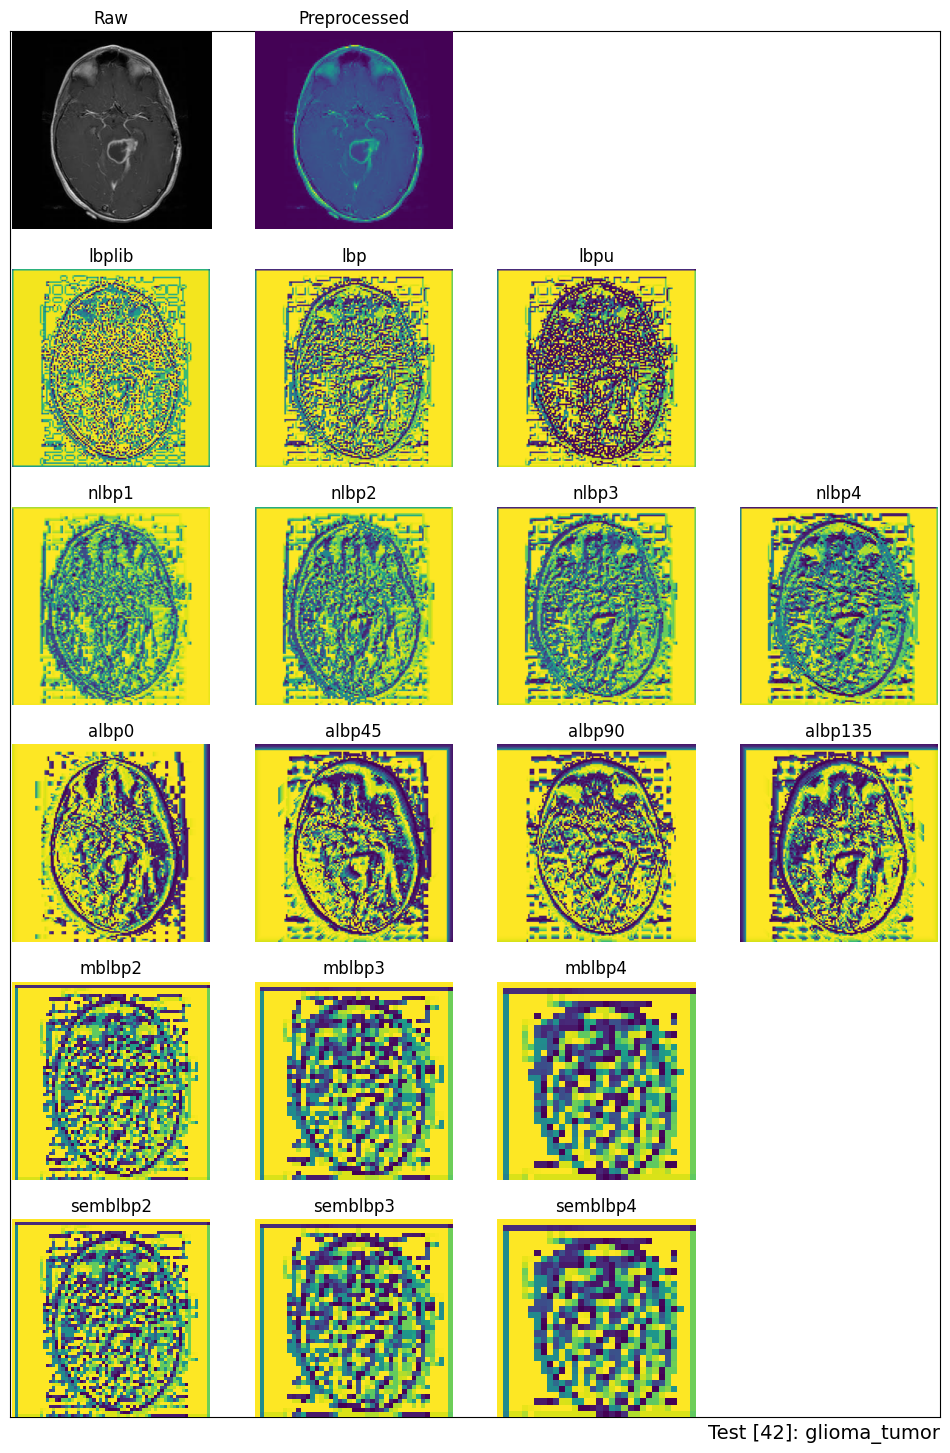

In [51]:
prvw_idx = 42
prvw_test_data = [X_test[prvw_idx], X_test_prep[prvw_idx]]
for f in X_test_feats:
    prvw_test_data.append(f[prvw_idx])

plt.figure(figsize=(12,18))
plt.xlabel(f"Test [{prvw_idx}]: {classes[y_test[prvw_idx]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

for i in range(len(prvw_titles)):
    get_image_preview(prvw_titles[i], prvw_test_data[i], prvw_img_pos[i])

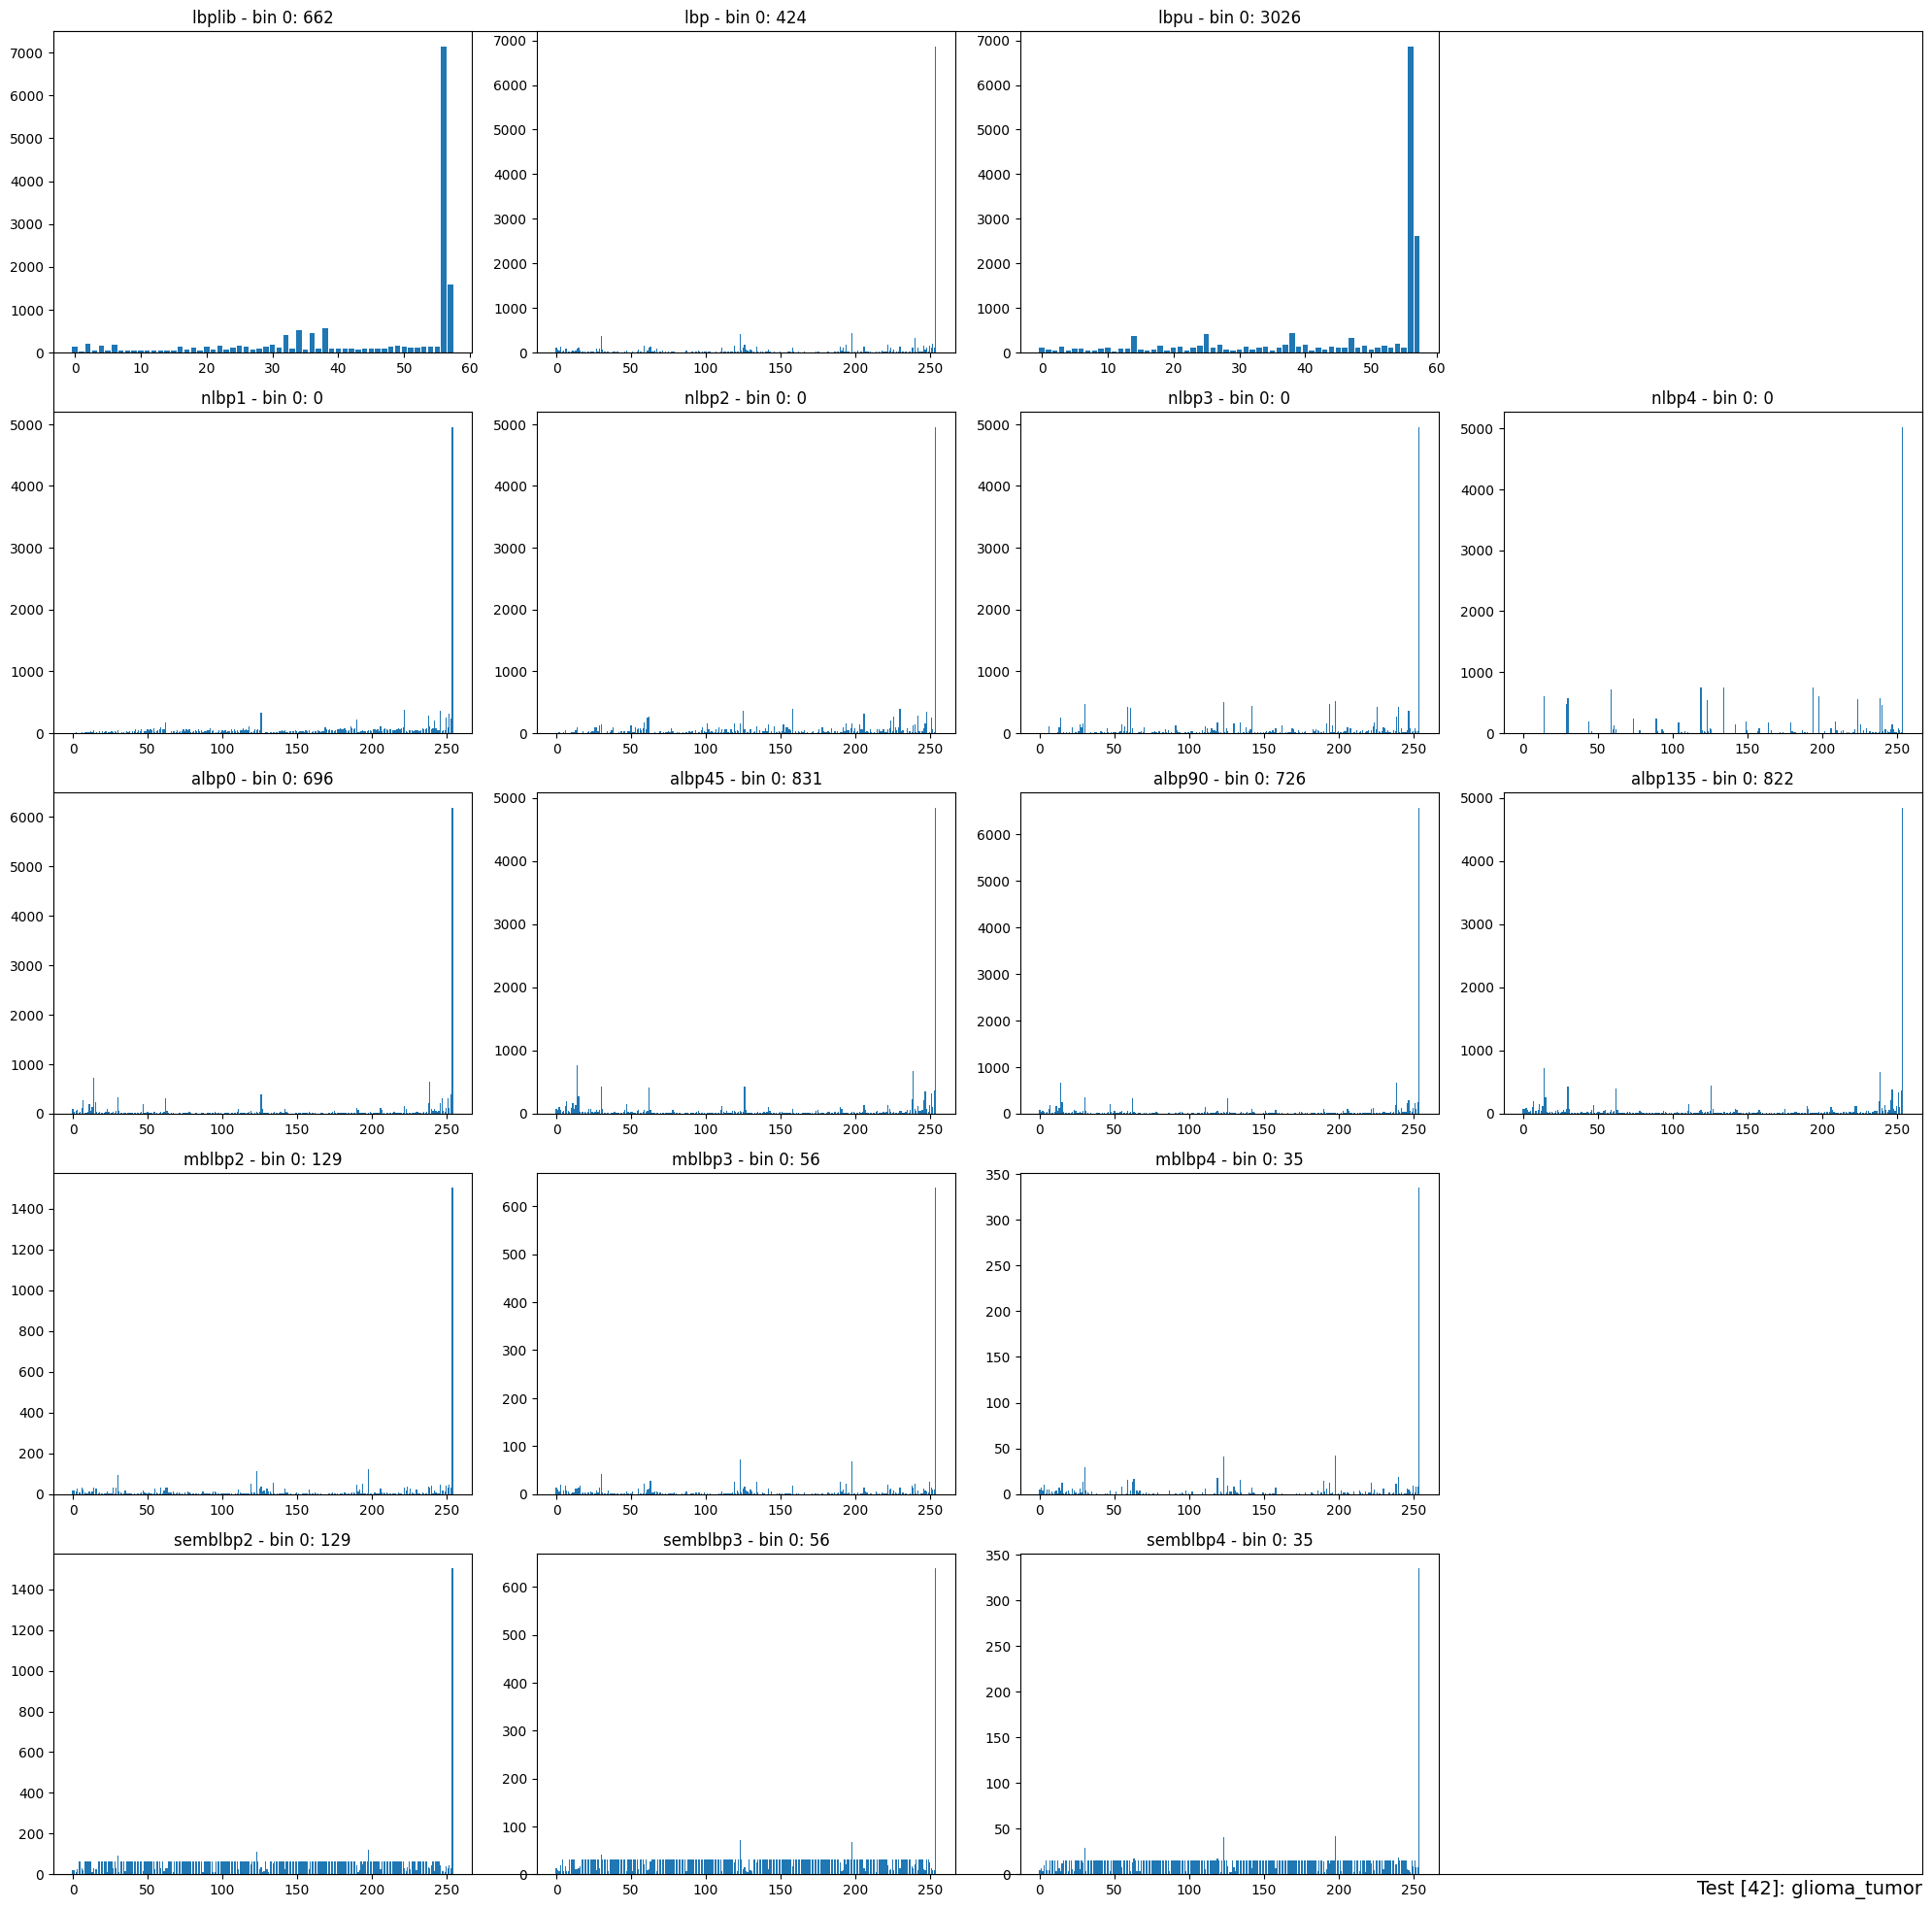

In [52]:
plt.figure(figsize=(20, 20))
plt.xlabel(f"Test [{prvw_idx}]: {classes[y_test[prvw_idx]]}", fontsize=14, loc="right")
plt.yticks([])
plt.xticks([])

# Preview all extracted histogram feature samples
for i in range(len(X_test_hists)):    
    get_histogram_preview(prvw_titles[2:][i], X_test_hists[i][prvw_idx], prvw_hist_pos[i])

plt.show()

#### Evaluation Process

--------------------------------- Best KNN | nlbp1 ---------------------------------


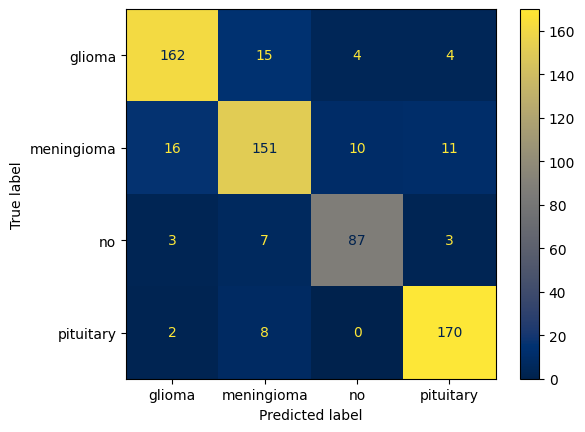

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.9326186830015314  	0.8852459016393442  	0.8756756756756757  	0.8804347826086957  
meningioma	0.8973966309341501  	0.8342541436464088  	0.8031914893617021  	0.8184281842818428  
no        	0.9586523736600306  	0.8613861386138614  	0.87                	0.8656716417910448  
pituitary 	0.9571209800918836  	0.9042553191489362  	0.9444444444444444  	0.9239130434782609  

> Global Performance
Accuracy (Micro) : 0.936447166921899
Accuracy (Macro) : 0.8728943338437979
Precision        : 0.8712853757621376
Recall           : 0.8733279023704557
F1-Score         : 0.872111913039961


In [53]:
knn_best_features = X_test_hists[FEATURES.index(knn_best["method"])]
knn_best_preds = knn_best["model"].predict(knn_best_features)
knn_best_eval = evaluate_model(knn_best_preds)
display_evaluation(f"Best KNN | {knn_best["method"]}", knn_best_eval)
# .94 .88

--------------------------------- Best DT | nlbp1 ---------------------------------


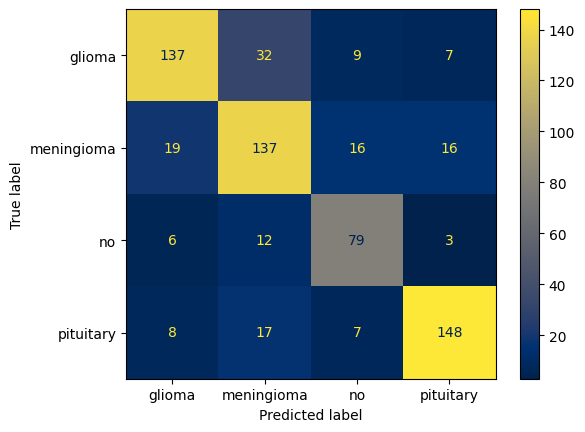

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.8759571209800919  	0.8058823529411765  	0.7405405405405405  	0.7718309859154929  
meningioma	0.8284839203675345  	0.6919191919191919  	0.7287234042553191  	0.7098445595854922  
no        	0.9188361408882083  	0.7117117117117117  	0.79                	0.7488151658767773  
pituitary 	0.9111791730474732  	0.8505747126436781  	0.8222222222222222  	0.8361581920903955  

> Global Performance
Accuracy (Micro) : 0.883614088820827
Accuracy (Macro) : 0.7672281776416539
Precision        : 0.7650219923039395
Recall           : 0.7703715417545205
F1-Score         : 0.7666622258670395


In [54]:
dt_best_features = X_test_hists[FEATURES.index(dt_best["method"])]
dt_best_preds = dt_best["model"].predict(dt_best_features)
dt_best_eval = evaluate_model(dt_best_preds)
display_evaluation(f"Best DT | {dt_best["method"]}", dt_best_eval)
# .86 .74

--------------------------------- Best RF | nlbp2 ---------------------------------


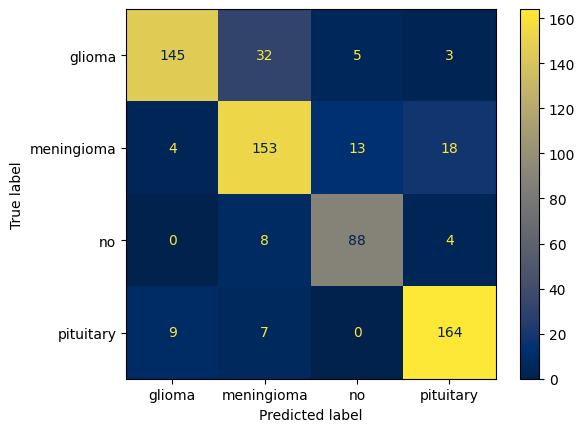

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.9188361408882083  	0.9177215189873418  	0.7837837837837838  	0.8454810495626821  
meningioma	0.8744257274119449  	0.765               	0.8138297872340425  	0.7886597938144329  
no        	0.9540581929555896  	0.8301886792452831  	0.88                	0.8543689320388349  
pituitary 	0.9372128637059725  	0.8677248677248677  	0.9111111111111111  	0.8888888888888887  

> Global Performance
Accuracy (Micro) : 0.9211332312404288
Accuracy (Macro) : 0.8422664624808576
Precision        : 0.8451587664893732
Recall           : 0.8471811705322343
F1-Score         : 0.8443496660762096


In [55]:
rf_best_features = X_test_hists[FEATURES.index(rf_best["method"])]
rf_best_preds = rf_best["model"].predict(rf_best_features)
rf_best_eval = evaluate_model(rf_best_preds)
display_evaluation(f"Best RF | {rf_best["method"]}", rf_best_eval)
# .91 .82

--------------------------------- Best MNB | nlbp1 ---------------------------------


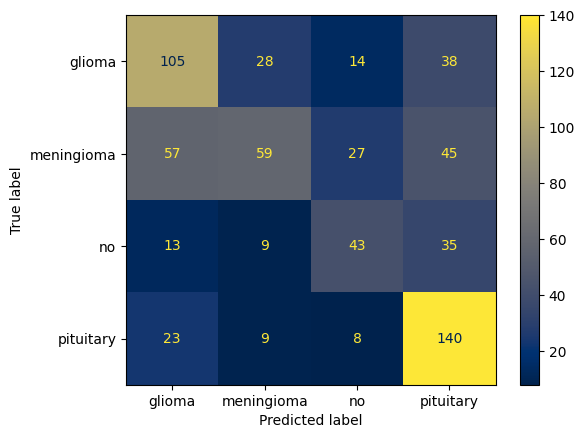

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.7350689127105666  	0.5303030303030303  	0.5675675675675675  	0.5483028720626631  
meningioma	0.7320061255742726  	0.5619047619047619  	0.31382978723404253 	0.40273037542662116 
no        	0.8376722817764165  	0.4673913043478261  	0.43                	0.4479166666666667  
pituitary 	0.7580398162327718  	0.5426356589147286  	0.7777777777777778  	0.639269406392694   

> Global Performance
Accuracy (Micro) : 0.7656967840735068
Accuracy (Macro) : 0.5313935681470138
Precision        : 0.5255586888675867
Recall           : 0.522293783144847
F1-Score         : 0.5095548301371613


In [56]:
mnb_best_features = X_test_hists[FEATURES.index(mnb_best["method"])]
mnb_best_preds = mnb_best["model"].predict(mnb_best_features)
mnb_best_eval = evaluate_model(mnb_best_preds)
display_evaluation(f"Best MNB | {mnb_best["method"]}", mnb_best_eval)
# .76 .49

--------------------------------- Best GNB | nlbp2 ---------------------------------


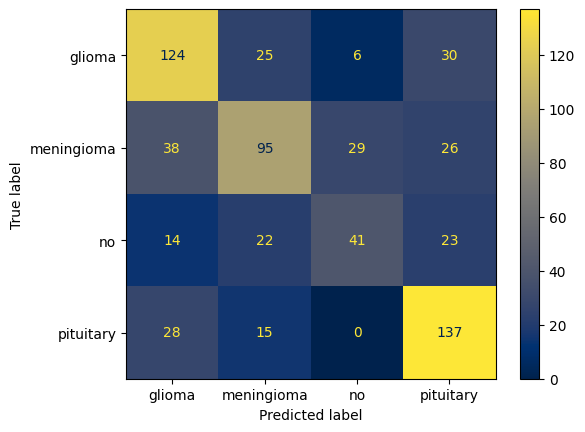

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.7840735068912711  	0.6078431372549019  	0.6702702702702703  	0.6375321336760926  
meningioma	0.7626339969372129  	0.6050955414012739  	0.5053191489361702  	0.5507246376811594  
no        	0.8560490045941807  	0.5394736842105263  	0.41                	0.46590909090909094 
pituitary 	0.8131699846860643  	0.6342592592592593  	0.7611111111111111  	0.6919191919191919  

> Global Performance
Accuracy (Micro) : 0.8039816232771821
Accuracy (Macro) : 0.6079632465543645
Precision        : 0.5966679055314903
Recall           : 0.586675132579388
F1-Score         : 0.5865212635463838


In [57]:
gnb_best_features = X_test_hists[FEATURES.index(gnb_best["method"])]
gnb_best_preds = gnb_best["model"].predict(gnb_best_features)
gnb_best_eval = evaluate_model(gnb_best_preds)
display_evaluation(f"Best GNB | {gnb_best["method"]}", gnb_best_eval)
# .76 .53

--------------------------------- Best SVM - Linear Kernel (LinearSVC) | nlbp2 ---------------------------------


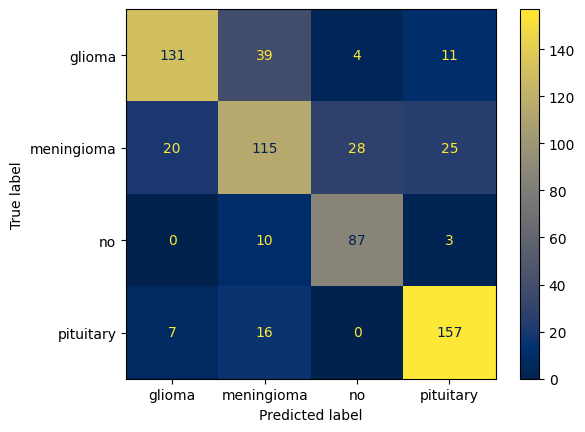

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.8759571209800919  	0.8291139240506329  	0.7081081081081081  	0.7638483965014577  
meningioma	0.7886676875957122  	0.6388888888888888  	0.6117021276595744  	0.625               
no        	0.9310872894333844  	0.7310924369747899  	0.87                	0.7945205479452055  
pituitary 	0.9050535987748851  	0.8010204081632653  	0.8722222222222222  	0.8351063829787234  

> Global Performance
Accuracy (Micro) : 0.8751914241960184
Accuracy (Macro) : 0.7503828483920367
Precision        : 0.7500289145193942
Recall           : 0.7655081144974762
F1-Score         : 0.7546188318563467


In [58]:
svm_linearlib_best_features = X_test_hists[FEATURES.index(svm_linearlib_best["method"])]
svm_linearlib_best_preds = svm_linearlib_best["model"].predict(svm_linearlib_best_features)
svm_linearlib_best_eval = evaluate_model(svm_linearlib_best_preds)
display_evaluation(f"Best SVM - Linear Kernel (LinearSVC) | {svm_linearlib_best["method"]}", svm_linearlib_best_eval)
# .87 .74

--------------------------------- Best SVM - Linear Kernel (SVC Library) | nlbp2 ---------------------------------


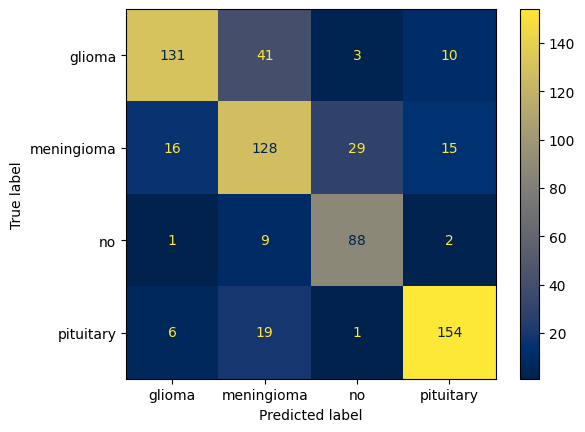

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.8820826952526799  	0.8506493506493507  	0.7081081081081081  	0.7728613569321534  
meningioma	0.8024502297090352  	0.649746192893401   	0.6808510638297872  	0.6649350649350649  
no        	0.9310872894333844  	0.7272727272727273  	0.88                	0.7963800904977375  
pituitary 	0.9188361408882083  	0.850828729281768   	0.8555555555555555  	0.8531855955678671  

> Global Performance
Accuracy (Micro) : 0.883614088820827
Accuracy (Macro) : 0.7672281776416539
Precision        : 0.7696242500243118
Recall           : 0.7811286818733627
F1-Score         : 0.7718405269832058


In [59]:
svm_linear_best_features = X_test_hists[FEATURES.index(svm_linear_best["method"])]
svm_linear_best_preds = svm_linear_best["model"].predict(svm_linear_best_features)
svm_linear_best_eval = evaluate_model(svm_linear_best_preds)
display_evaluation(f"Best SVM - Linear Kernel (SVC Library) | {svm_linear_best["method"]}", svm_linear_best_eval)
# .87 .75

--------------------------------- Best SVM - Polynomial Kernel | nlbp1 ---------------------------------


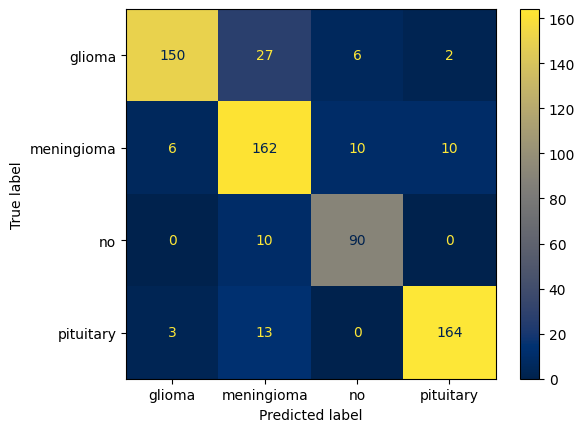

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.9326186830015314  	0.9433962264150944  	0.8108108108108109  	0.8720930232558141  
meningioma	0.8836140888208269  	0.7641509433962265  	0.8617021276595744  	0.8099999999999999  
no        	0.9601837672281777  	0.8490566037735849  	0.9                 	0.8737864077669903  
pituitary 	0.9571209800918836  	0.9318181818181818  	0.9111111111111111  	0.9213483146067416  

> Global Performance
Accuracy (Micro) : 0.933384379785605
Accuracy (Macro) : 0.8667687595712098
Precision        : 0.8721054888507719
Recall           : 0.870906012395374
F1-Score         : 0.8693069364073864


In [60]:
svm_polynomial_best_features = X_test_hists[FEATURES.index(svm_polynomial_best["method"])]
svm_polynomial_best_preds = svm_polynomial_best["model"].predict(svm_polynomial_best_features)
svm_polynomial_best_eval = evaluate_model(svm_polynomial_best_preds)
display_evaluation(f"Best SVM - Polynomial Kernel | {svm_polynomial_best["method"]}", svm_polynomial_best_eval)
# .92 .84

--------------------------------- Best SVM - Sigmoid Kernel | nlbp4 ---------------------------------


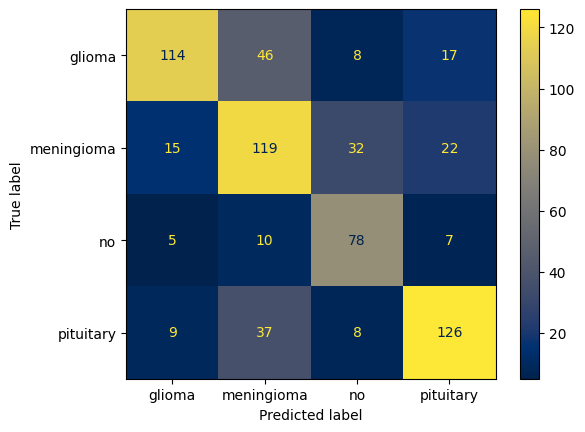

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.8468606431852986  	0.7972027972027972  	0.6162162162162163  	0.6951219512195123  
meningioma	0.7519142419601837  	0.5613207547169812  	0.6329787234042553  	0.5950000000000001  
no        	0.892802450229709   	0.6190476190476191  	0.78                	0.6902654867256637  
pituitary 	0.8468606431852986  	0.7325581395348837  	0.7                 	0.7159090909090908  

> Global Performance
Accuracy (Micro) : 0.8346094946401226
Accuracy (Macro) : 0.669218989280245
Precision        : 0.6775323276255703
Recall           : 0.6822987349051179
F1-Score         : 0.6740741322135667


In [61]:
svm_sigmoid_best_features = X_test_hists[FEATURES.index(svm_sigmoid_best["method"])]
svm_sigmoid_best_preds = svm_sigmoid_best["model"].predict(svm_sigmoid_best_features)
svm_sigmoid_best_eval = evaluate_model(svm_sigmoid_best_preds)
display_evaluation(f"Best SVM - Sigmoid Kernel | {svm_sigmoid_best["method"]}", svm_sigmoid_best_eval)
# .81 .64

--------------------------------- Best SVM - RBF Kernel | lbpu ---------------------------------


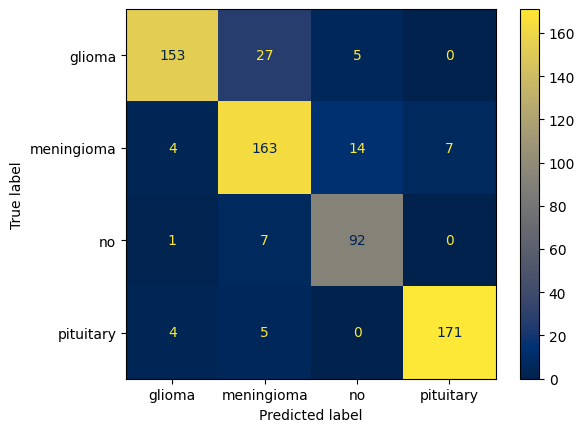

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.9372128637059725  	0.9444444444444444  	0.827027027027027   	0.8818443804034583  
meningioma	0.9019908116385911  	0.806930693069307   	0.8670212765957447  	0.835897435897436   
no        	0.9586523736600306  	0.8288288288288288  	0.92                	0.8720379146919431  
pituitary 	0.9754977029096478  	0.9606741573033708  	0.95                	0.9553072625698323  

> Global Performance
Accuracy (Micro) : 0.9433384379785604
Accuracy (Macro) : 0.886676875957121
Precision        : 0.8852195309114878
Recall           : 0.891012075905693
F1-Score         : 0.8862717483906675


In [62]:
svm_rbf_best_features = X_test_hists[FEATURES.index(svm_rbf_best["method"])]
svm_rbf_best_preds = svm_rbf_best["model"].predict(svm_rbf_best_features)
svm_rbf_best_eval = evaluate_model(svm_rbf_best_preds)
display_evaluation(f"Best SVM - RBF Kernel | {svm_rbf_best["method"]}", svm_rbf_best_eval)
# .93 .87

## Deep Learning

#### DL - Preprocessing

In [63]:
# Data preprocessing function for deep learning classifiers
def preprocess_dl(images):
    preprocessed = []

    for img in images:
        # Resize image into same size
        img_resized = cv.resize(img, (CNN_IMAGE_SIZE, CNN_IMAGE_SIZE))

        # Convert image from BGR (default configuration of MRI image dataset) 
        # to RGB (preferred image channel for CNN model)
        img_rgb = cv.cvtColor(img_resized, cv.COLOR_BGR2RGB)

        # Normalize image pixel intensity values into 0-1 range
        img_normalized = img_rgb / 255

        preprocessed.append(img_normalized)
    
    return preprocessed

In [64]:
# Preprocess dataset for deep learning classifier using the same data as machine learning classifiers
X_train_cnn = np.array(preprocess_dl(X_train))
y_train_cnn = np.array(y_train.copy())

X_test_cnn = np.array(preprocess_dl(X_test))
y_test_cnn = np.array(y_test.copy())

print("X_train\t\ty_train\t")
print(f"{len(X_train)}\t\t{len(y_train)}\n")
print("X_train_cnn\ty_train_cnn\t")
print(f"{len(X_train_cnn)}\t\t{len(y_train_cnn)}\n")
print("X_test_cnn\ty_test_cnn\t")
print(f"{len(X_test_cnn)}\t\t{len(y_test_cnn)}\t")

X_train		y_train	
2611		2611

X_train_cnn	y_train_cnn	
2611		2611

X_test_cnn	y_test_cnn	
653		653	


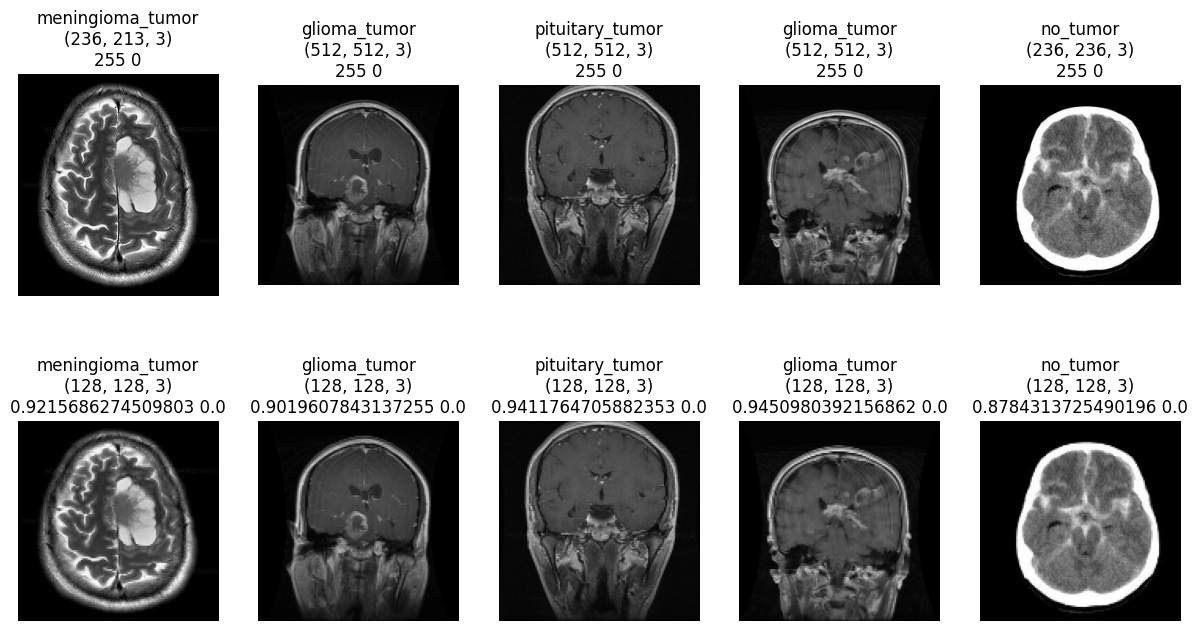

In [65]:
# Display sample raw and preprocessed images
plt.figure(figsize=(15, 8))
for i in range(1, 11):
    plt.subplot(2, 5, i)
    plt.axis("off")
    if(i<=5): 
        plt.title(f"{classes[y_train[i]]}\n{str(X_train[i].shape)}\n{X_train[i].max()} {X_train[i].min()}")
        plt.imshow(X_train[i])
    else: 
        plt.title(f"{classes[y_train[i-5]]}\n{str(X_train_cnn[i-5].shape)}\n{X_train_cnn[i].max()} {X_train_cnn[i].min()}")
        plt.imshow(X_train_cnn[i-5])

plt.show()

### DL - Modelling

In [66]:
# Build CNN model architecture
cnn_model = keras.Sequential([
    layers.Input(shape=(CNN_IMAGE_SIZE, CNN_IMAGE_SIZE, 3)), 
    
    # layers.RandomFlip(),
    # layers.RandomRotation(factor=.2),

    layers.Conv2D(filters=32, kernel_size=(3,3), 
                  activation='relu', padding='same'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=64, kernel_size=(3,3),
                  activation='relu', padding='same'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=128, kernel_size=(3,3),
                  activation='relu', padding='same'),
    layers.MaxPool2D((2,2)),

    layers.Conv2D(filters=256, kernel_size=(3,3),
                  activation='relu', padding='same'),
    layers.MaxPool2D((2,2)),

    layers.Flatten(),
    
    layers.Dense(units=512, activation='relu'),
    layers.Dropout(rate=0.5), # Overfit handling
    layers.Dense(units=256, activation='relu'),
    layers.Dense(units=128, activation='relu'),
    layers.Dropout(rate=0.2),

    layers.Dense(units=4, activation='softmax')
])

cnn_model.summary()

E0000 00:00:1777524244.353355    7692 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1777524244.367067    7692 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │     8,389,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,942,276 (34.11 MB)

 Trainable params: 8,942,276 (34.11 MB)

 Non-trainable params: 0 (0.00 B)

In [67]:
# Set CNN model parameters and configurations
cnn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=[keras.metrics.sparse_categorical_accuracy]
)

cnn_model.get_compile_config()

{'optimizer': {'module': 'keras.optimizers',
  'class_name': 'Adam',
  'config': {'name': 'adam',
   'learning_rate': 0.0010000000474974513,
   'weight_decay': None,
   'clipnorm': None,
   'global_clipnorm': None,
   'clipvalue': None,
   'use_ema': False,
   'ema_momentum': 0.99,
   'ema_overwrite_frequency': None,
   'loss_scale_factor': None,
   'gradient_accumulation_steps': None,
   'beta_1': 0.9,
   'beta_2': 0.999,
   'epsilon': 1e-07,
   'amsgrad': False},
  'registered_name': None},
 'loss': 'sparse_categorical_crossentropy',
 'loss_weights': None,
 'metrics': [{'module': 'builtins',
   'class_name': 'function',
   'config': 'sparse_categorical_accuracy',
   'registered_name': 'function'}],
 'weighted_metrics': None,
 'run_eagerly': False,
 'steps_per_execution': 1,
 'jit_compile': False}

In [68]:
# Early stopping to handle overfit
cnn_early_stopping = EarlyStopping(monitor="val_loss",
                                   patience=5,
                                   restore_best_weights=True, 
                                   verbose=1)

In [69]:
cnn_start = time.perf_counter()

# Train and validate CNN model
cnn_history = cnn_model.fit(
    X_train_cnn,
    y_train_cnn,
    epochs=50,
    batch_size=16,
    validation_split=0.2,   
    callbacks=[cnn_early_stopping]
)

print(f"Best val_loss: {cnn_early_stopping.best}")
print(f"\nCNN Model Built in {time.perf_counter() - cnn_start}s")

# .01 .99 .76 .90 best train
# .18 .94 .34 .88 best val - 4 layer blocks

Epoch 1/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 14s 92ms/step - loss: 1.1804 - sparse_categorical_accuracy: 0.4516 - val_loss: 1.0163 - val_sparse_categorical_accuracy: 0.5889
Epoch 2/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 88ms/step - loss: 0.8716 - sparse_categorical_accuracy: 0.6173 - val_loss: 0.7473 - val_sparse_categorical_accuracy: 0.6864
Epoch 3/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 93ms/step - loss: 0.7381 - sparse_categorical_accuracy: 0.6753 - val_loss: 0.6680 - val_sparse_categorical_accuracy: 0.7151
Epoch 4/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 96ms/step - loss: 0.6415 - sparse_categorical_accuracy: 0.7347 - val_loss: 0.5839 - val_sparse_categorical_accuracy: 0.7629
Epoch 5/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 92ms/step - loss: 0.4967 - sparse_categorical_accuracy: 0.8022 - val_loss: 0.5570 - val_sparse_categorical_accuracy: 0.7992
Epoch 6/50
131/131 ━━━━━━━━━━━━━━━━━━━━ 12s 90ms/step - loss: 0.3821 - sparse_categorical_accuracy: 0.8396 - val_loss: 0.4236 - val_sparse_categorical_accuracy:

In [70]:
cnn_best_idx = cnn_history.history["val_loss"].index(min(cnn_history.history["val_loss"]))

print("Best Loss\t\t:", cnn_history.history["loss"][cnn_best_idx])
print("Best Accuracy\t\t:", cnn_history.history["sparse_categorical_accuracy"][cnn_best_idx])
print("Best Validation Loss\t:", cnn_history.history["val_loss"][cnn_best_idx])
print("Best Validation Accuracy:", cnn_history.history["val_sparse_categorical_accuracy"][cnn_best_idx])

Best Loss		: 0.19468621909618378
Best Accuracy		: 0.9295976758003235
Best Validation Loss	: 0.3978162109851837
Best Validation Accuracy: 0.894837498664856


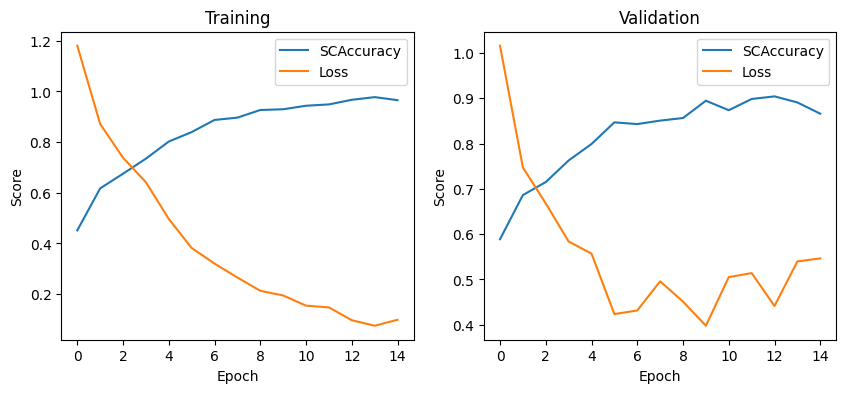

In [71]:
plt.figure(figsize=(10,4))

# Plot training set performance score graph
plt.subplot(1,2,1)
plt.title("Training")
plt.plot(cnn_history.history["sparse_categorical_accuracy"])
plt.plot(cnn_history.history["loss"])
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend(["SCAccuracy", "Loss"])

# Plot validation set performance score graph
plt.subplot(1,2,2)
plt.title("Validation")
plt.plot(cnn_history.history["val_sparse_categorical_accuracy"])
plt.plot(cnn_history.history["val_loss"])
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend(["SCAccuracy", "Loss"])

plt.show()

### DL - Evaluation

In [72]:
# Test and evaluate CNN model performance with unseen test data
cnn_loss, cnn_accuracy = cnn_model.evaluate(
    X_test_cnn,
    y_test_cnn,
)

print("SC Accuracy >", cnn_accuracy)
print("Loss        >", cnn_loss)
# .871 .378

21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 0.4622 - sparse_categorical_accuracy: 0.8652
SC Accuracy > 0.8652373552322388
Loss        > 0.46220558881759644


21/21 ━━━━━━━━━━━━━━━━━━━━ 1s 37ms/step
--------------------------------- CNN ---------------------------------


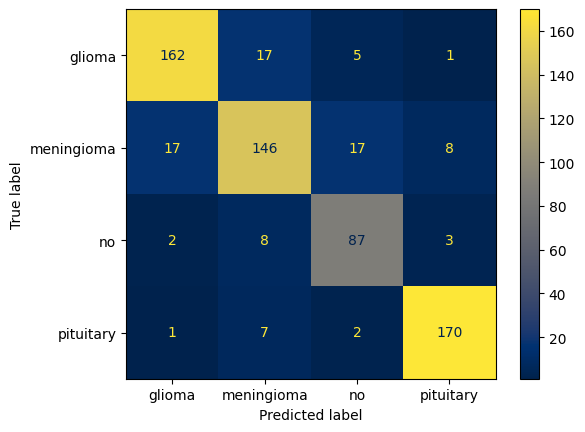

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.9341500765696784  	0.8901098901098901  	0.8756756756756757  	0.8828337874659401  
meningioma	0.886676875957121   	0.8202247191011236  	0.776595744680851   	0.7978142076502731  
no        	0.9433384379785605  	0.7837837837837838  	0.87                	0.8246445497630331  
pituitary 	0.9663093415007658  	0.9340659340659341  	0.9444444444444444  	0.9392265193370165  

> Global Performance
Accuracy (Micro) : 0.9326186830015314
Accuracy (Macro) : 0.8652373660030628
Precision        : 0.8570460817651828
Recall           : 0.8666789662002428
F1-Score         : 0.8611297660540658


In [73]:
cnn_pred = cnn_model.predict(X_test_cnn)
# Convert probability predictions into classes
cnn_pred_classes = np.argmax(cnn_pred, axis=1)

# Evaluate and display model performance result
cnn_eval = evaluate_model(cnn_pred_classes)
display_evaluation("CNN", cnn_eval)

## Explainable AI - LIME

### XAI: Best Model

#### Acquire Best SVM Kernel + Feature Extraction Method Combination

In [74]:
# Store built SVM models and evaluations result
svm_best_kernels = ["Linear (Lib)", "Linear (SVC)", "Polynomial", "Sigmoid", "RBF"]
svm_best_models = [svm_linearlib_best, svm_linear_best, svm_polynomial_best, svm_sigmoid_best, svm_rbf_best]
svm_best_evals = [svm_linearlib_best_eval, svm_linear_best_eval, svm_polynomial_best_eval, svm_sigmoid_best_eval, svm_rbf_best_eval]

# Sort and get best SVM kernel performance
svm_best_sorted = [x for _, x in sorted(zip(svm_best_evals, svm_best_models), key=lambda x:x[0]["global"]["f1-score"], reverse=True)]
svm_best = svm_best_sorted[0]

print("Kernel\t", "LBP Var", "F1-Score\t", "Accuracy", sep="\t\t")
for i in range(len(svm_best_evals)):
    print(str(svm_best_kernels[i]).ljust(12), svm_best_models[i]["method"], svm_best_evals[i]["global"]["f1-score"], svm_best_evals[i]["global"]["accuracy"], sep="\t\t")

print(f"\n> Best SVM Model")
print("Pipeline:", svm_best["model"].best_estimator_.named_steps)
print("Kernel\t:", svm_best["model"].best_params_["classifier__kernel"])
print("Method\t:", svm_best["method"])
print("CV Time\t:", svm_best["time"])

Kernel			LBP Var		F1-Score			Accuracy
Linear (Lib)		nlbp2		0.7546188318563467		0.8751914241960184
Linear (SVC)		nlbp2		0.7718405269832058		0.883614088820827
Polynomial  		nlbp1		0.8693069364073864		0.933384379785605
Sigmoid     		nlbp4		0.6740741322135667		0.8346094946401226
RBF         		lbpu		0.8862717483906675		0.9433384379785604

> Best SVM Model
Pipeline: {'scaler': StandardScaler(), 'classifier': SVC(C=10, decision_function_shape='ovo', gamma=0.1, random_state=42)}
Kernel	: rbf
Method	: lbpu
CV Time	: 1.936390924999614


#### Retrain Best Model using Probability

In [75]:
svm_rbf_prob_time_start = time.perf_counter()

# Convert SVM best params set values into list type for cross validation step
svm_best_params = svm_best["model"].best_params_
svm_new_params = {
    "classifier__kernel": [svm_best_params["classifier__kernel"]],
    "classifier__C": [svm_best_params["classifier__C"]],
    "classifier__gamma": [svm_best_params["classifier__gamma"]],
    "classifier__decision_function_shape": [svm_best_params["classifier__decision_function_shape"]],
    "classifier__probability": [True],
}

# Histogram features of best feature extraction methods used by SVM and its kernel
svm_best_feature = X_train_hists[FEATURES.index(svm_best["method"])]

svm_rbf_prob_title = "(Scaled) Support Vector Machine - RBF Kernel (Probability)"
svm_rbf_prob_base_model = SVC(random_state=42)
svm_rbf_prob_param_grid = svm_new_params

print("   Method\tScore\t\tTime\t\tParameters")
svm_rbf_prob_best = get_model(0, svm_best["method"], svm_rbf_prob_base_model, svm_new_params, svm_best_feature, scale=True)

print(f"\nCompleted in {time.perf_counter() - svm_rbf_prob_time_start}s")
# .870 2.44

   Method	Score		Time		Parameters
0  lbpu 	0.871588	4.081719s 	{'classifier__C': 10, 'classifier__decision_function_shape': 'ovo', 'classifier__gamma': 0.1, 'classifier__kernel': 'rbf', 'classifier__probability': True}

Completed in 4.082340011999804s


#### Evaluate Probability SVM

--------------------------------- Best SVM (Probability) - RBF Kernel | lbpu ---------------------------------


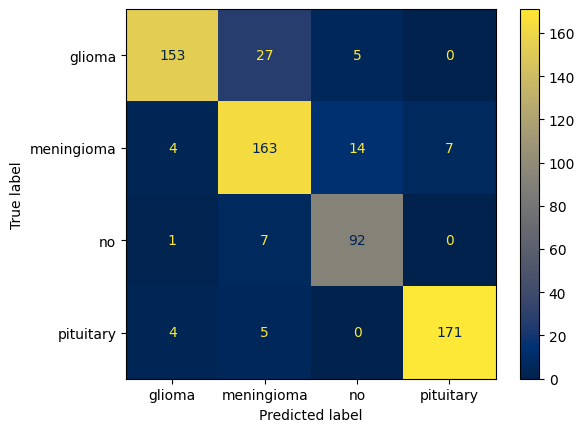

> Local Performance
Class		Accuracy		Precision		Recall			F1-Score
glioma    	0.9372128637059725  	0.9444444444444444  	0.827027027027027   	0.8818443804034583  
meningioma	0.9019908116385911  	0.806930693069307   	0.8670212765957447  	0.835897435897436   
no        	0.9586523736600306  	0.8288288288288288  	0.92                	0.8720379146919431  
pituitary 	0.9754977029096478  	0.9606741573033708  	0.95                	0.9553072625698323  

> Global Performance
Accuracy (Micro) : 0.9433384379785604
Accuracy (Macro) : 0.886676875957121
Precision        : 0.8852195309114878
Recall           : 0.891012075905693
F1-Score         : 0.8862717483906675


In [76]:
svm_rbf_prob_best_method = X_test_hists[FEATURES.index(svm_rbf_prob_best["method"])]
svm_rbf_prob_best_preds = svm_rbf_prob_best["model"].predict(svm_rbf_prob_best_method)
svm_rbf_prob_best_eval = evaluate_model(svm_rbf_prob_best_preds)
display_evaluation(f"Best SVM (Probability) - RBF Kernel | {svm_rbf_prob_best["method"]}", svm_rbf_prob_best_eval)
# .93 .87

### XAI: Train LIME Explanation

In [86]:
# Classifier function for LIME image processing
def svm_classifier_fn(images):
    features = []

    # Same processes as the steps used in previous machine learning modelling
    for img in images:
        img_resized = cv.resize(img, (IMAGE_SIZE, IMAGE_SIZE))
        img_grayscaled = cv.cvtColor(img_resized, cv.COLOR_BGR2GRAY)
        _, hist_best = get_feature_histogram(img_grayscaled, svm_rbf_prob_best["method"]) 
        features.append(hist_best)

    # Probability prediction of the best SVM model
    svm_pred = svm_rbf_prob_best["model"].predict_proba(np.array(features))
    return svm_pred

In [ ]:
sample_idxs = [30, 31, 32, 33]
explanations = []

explainer = lime_image.LimeImageExplainer()

# Explain each sample images
for idx in sample_idxs:
    explanation = explainer.explain_instance(
        X_test[idx],
        svm_classifier_fn,
        top_labels=1,
        hide_color=None,
        num_samples=2000,
        random_seed=42
    )
    
    explanations.append(explanation)

100%|██████████| 2000/2000 [01:15<00:00, 26.53it/s]


### XAI: LIME Explanation Visualization

30 > Pred: no_tumor | True: no_tumor
31 > Pred: pituitary_tumor | True: pituitary_tumor
32 > Pred: glioma_tumor | True: glioma_tumor
33 > Pred: meningioma_tumor | True: meningioma_tumor


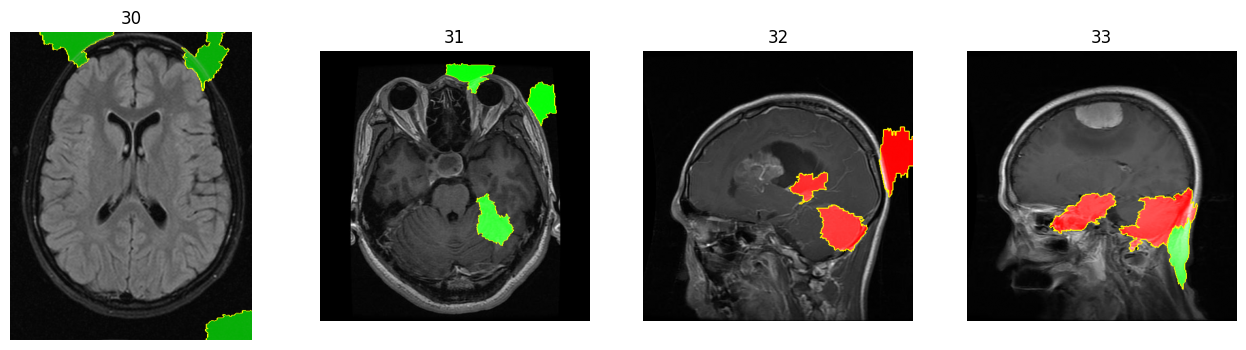

In [79]:
plt.figure(figsize=(16,4))
for i, exp in enumerate(explanations):
    # Display explanation result
    image, mask = exp.get_image_and_mask(exp.top_labels[0],
                                        positive_only=False,
                                        num_features=3,
                                        hide_rest=False)

    print(sample_idxs[i], "> Pred:", classes[exp.top_labels[0]], "| True:", classes[y_test[sample_idxs[i]]])
    plt.subplot(1, len(explanations), i+1)
    plt.imshow(mark_boundaries(image, mask))
    plt.axis("off")
    plt.title(sample_idxs[i])

plt.show()

## Save Model

In [80]:
directory = "output"

ml_titles = ["knn", "dt", "rf", "mnb", "gnb"]
ml_models = [knn_best, dt_best, rf_best, mnb_best, gnb_best]

svm_titles = ["linearlib", "linear", "polynomial", "sigmoid", "rbf"]
svm_models = [svm_linearlib_best, svm_linear_best, svm_polynomial_best, svm_sigmoid_best, svm_rbf_best]

cnn_filename = "cnn_model.pkl"
best_svm_filename = "best_svm.pkl"
lime_filename = "lime_explanations.pkl"

# Create output directory
if(not os.path.exists(directory)): os.mkdir(directory)

In [81]:
# Save trained machine learning models
for i in range(len(ml_models)):
    pickle.dump(ml_models[i], open(f"{directory}/ml_{ml_titles[i]}.pkl", "wb"))

In [82]:
# Save trained SVM models
for i in range(len(svm_models)):
    pickle.dump(svm_models[i], open(f"{directory}/svm_{svm_titles[i]}.pkl", "wb"))

In [83]:
# Save best trained SVM model
pickle.dump(svm_rbf_prob_best, open(f"{directory}/{best_svm_filename}", "wb"))

In [84]:
# Save trained LIME explanations
pickle.dump(explanations, open(f"{directory}/{lime_filename}", "wb"))